In [2]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(readr)
library(jsonlite)
library(ggplot2)
library(tidyr)
library(ggpubr)
library(emmeans)
library(purrr)
library(ggsignif)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Warning message:
“package ‘ggpubr’ was built under R version 4.3.3”
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'


Attaching package: ‘purrr’


The following object is masked from ‘package:jsonlite’:

    flatten


The following object is masked from ‘package:caret’:

    l

In [2]:
load("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison.Rdata")

In [3]:
load("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison_ttest_nature.Rdata")

In [1]:
load("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison_cross_cohort.Rdata")

In [39]:
# results <- readRDS("/vol/projects/yzhang/500FG_aging/output/12_prediction/spearman/original_size_with_methy_spear/multi_prediction_results_original_methy_separ.rds")                   

In [3]:
# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)
                        
# Extract number of selected features for each iteration
num_selected_features <- sapply(results, function(x) length(x$selected_features))
                                
# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²",
             "Number of Selected Features"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values),
           mean(num_selected_features, na.rm = TRUE)), 
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values),
         sd(num_selected_features, na.rm = TRUE)) 
)
                              
# Print summary
print(metrics_summary)
                                                        
# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

                       Metric         Mean           SD
1                  Train RMSE    1.4951727   0.50716533
2             Validation RMSE    3.5077687   0.48633632
3                   Train MSE    2.4901861   1.48106706
4              Validation MSE   12.5385991   3.60325410
5                    Train R²    0.9836679   0.01103460
6               Validation R²    0.9115947   0.03738632
7 Number of Selected Features 4331.2700000 256.10638789


In [5]:
# head(plot_data_r2)
# write.csv(plot_data_r2,file="/vol/projects/yzhang/500FG_aging/output/12_prediction/spearman/original_size_with_methy_spear/elasticnet_orig_with_methy_separplot_data_r2.csv")

,Set,R2
,<chr>,<dbl>
1,Training,0.9907081
2,Training,0.9715669
3,Training,0.9820561
4,Training,0.9902706
5,Training,0.9814992
6,Training,0.9582461


In [14]:
tabpfn <- read.csv("/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/model_results_300bcg_external_with_methy_share_feattop235.csv")
head(tabpfn)

,Model,Iteration,Train_R2,Test_R2,External_R2,Train_RMSE,Test_RMSE,External_RMSE,Train_MSE,Test_MSE,External_MSE
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TabPFN,1,0.9861477,0.9491405,0.8863229,1.470556,3.667011,4.438085,2.162535,13.446968,19.69660
2,TabPFN,2,0.9899499,0.9661184,0.8853732,1.238447,2.966618,5.308985,1.533750,8.800823,28.18533
3,TabPFN,3,0.9822147,0.8239819,0.8063196,1.765089,4.638931,7.004709,3.115539,21.519677,49.06594
4,TabPFN,4,0.9869755,0.9614603,0.8779896,1.311251,2.615918,4.440516,1.719380,6.843028,19.71818
5,TabPFN,5,0.9876411,0.9310339,0.9141840,1.331928,3.424897,3.609033,1.774031,11.729919,13.02512
6,TabPFN,6,0.9851710,0.9366146,0.8626658,1.358598,3.706381,4.934813,1.845788,13.737256,24.35238


In [37]:
four_orig <- read.csv("/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/model_results_300bcg_external_with_methy_share_feat_fdr005.csv")
head(four_orig)

,Model,Iteration,Train_R2,Test_R2,External_R2,Train_RMSE,Test_RMSE,External_RMSE,Train_MSE,Test_MSE,External_MSE
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ElasticNet,1,0.9901646,0.9317739,0.8570368,1.23319336,3.255911,5.672546,1.520765865,10.60096,32.17777
2,ElasticNet,2,0.9908157,0.9315783,0.8497838,1.16232432,3.298726,5.574683,1.350997819,10.88159,31.07709
3,ElasticNet,3,0.9998613,0.8777805,0.8870500,0.15202536,3.978236,5.806928,0.023111711,15.82636,33.72041
4,ElasticNet,4,0.9999678,0.9356937,0.8289722,0.06780242,3.273506,5.391284,0.004597169,10.71584,29.06594
5,ElasticNet,5,0.9876396,0.9055385,0.8229477,1.31990001,3.735397,6.893893,1.742136030,13.95319,47.52577
6,ElasticNet,6,0.9724760,0.9472385,0.8602328,1.85023108,3.259440,5.266457,3.423355033,10.62395,27.73557


In [5]:
unique(tabpfn$Model)

[1] "TabPFN"       "ElasticNet"   "RandomForest" "XGBoost"      "CatBoost"

In [2]:
# 提取 tabpfn 中 Model 为 TabPFN 的行
tabpfn_selected <- subset(tabpfn, Model == "TabPFN")

# 提取 four_orig 中 Model 为 ElasticNet、RandomForest、XGBoost、CatBoost 的行
four_orig_selected <- subset(four_orig, Model %in% c("ElasticNet", "RandomForest", "XGBoost", "CatBoost"))

# 合并两个数据框
combined <- rbind(tabpfn_selected, four_orig_selected)

# 查看结果
head(combined)

,Model,Iteration,Train_R2,Test_R2,External_R2,Train_RMSE,Test_RMSE,External_RMSE,Train_MSE,Test_MSE,External_MSE
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TabPFN,1,0.9861477,0.9491405,0.8863229,1.470556,3.667011,4.438085,2.162535,13.446968,19.69660
2,TabPFN,2,0.9899499,0.9661184,0.8853732,1.238447,2.966618,5.308985,1.533750,8.800823,28.18533
3,TabPFN,3,0.9822147,0.8239819,0.8063196,1.765089,4.638931,7.004709,3.115539,21.519677,49.06594
4,TabPFN,4,0.9869755,0.9614603,0.8779896,1.311251,2.615918,4.440516,1.719380,6.843028,19.71818
5,TabPFN,5,0.9876411,0.9310339,0.9141840,1.331928,3.424897,3.609033,1.774031,11.729919,13.02512
6,TabPFN,6,0.9851710,0.9366146,0.8626658,1.358598,3.706381,4.934813,1.845788,13.737256,24.35238


In [7]:
# 提取 tabpfn 中 Model 为 TabPFN 的行
tabpfn_selected <- subset(tabpfn, Model == "TabPFN")

mean_selected <- mean(tabpfn_selected$Test_R2, na.rm = TRUE)
n_selected <- nrow(tabpfn_selected)
sd_selected <- sd(tabpfn_selected$Test_R2, na.rm = TRUE)

cat(paste(round(mean_selected, 4), "±", round(sd_selected, 4)))

0.918 ± 0.0503

In [8]:
unique(combined$Model)

[1] "TabPFN"       "ElasticNet"   "RandomForest" "XGBoost"      "CatBoost"

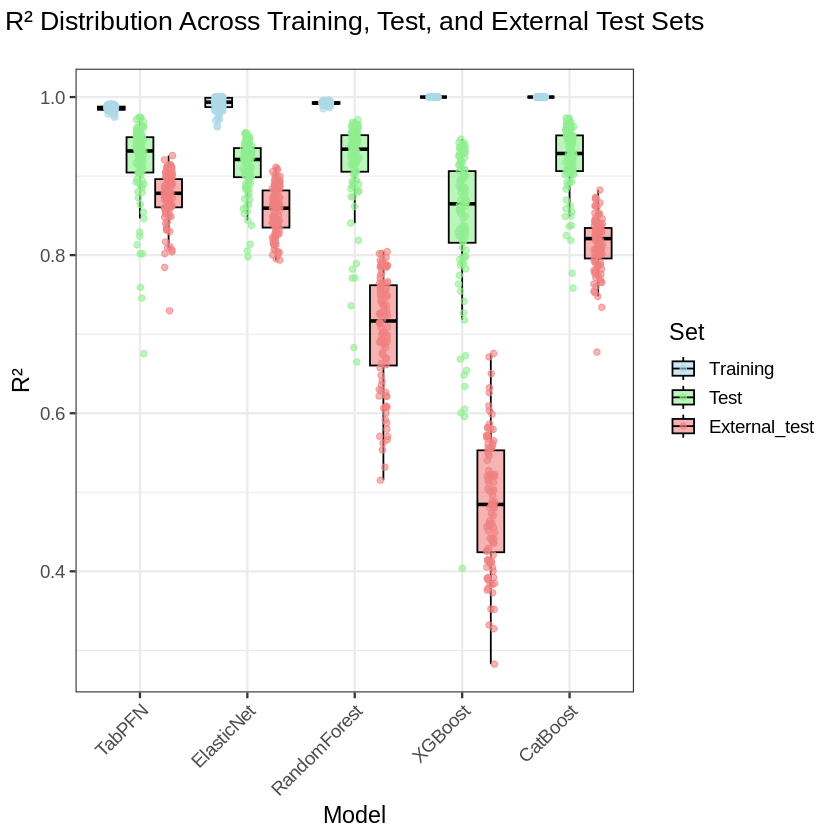

In [9]:
# 假设你的数据中有 External_R2 列
plot_df <- combined %>%
  select(Model, Iteration, Train_R2, Test_R2, External_R2)  # 添加 External_R2

# 转成长格式，包含三个集合
plot_df_long <- plot_df %>%
  pivot_longer(
    cols = c(Train_R2, Test_R2, External_R2),  # 添加 External_R2
    names_to = "Set",
    values_to = "R2"
  ) %>%
  mutate(Set = case_when(
    Set == "Train_R2" ~ "Training",
    Set == "Test_R2" ~ "Test", 
    Set == "External_R2" ~ "External_test"  # 添加映射
  ))
##make sure the order
plot_df_long$Model <- factor(
  plot_df_long$Model,
  levels = c("TabPFN", "ElasticNet", "RandomForest", "XGBoost", "CatBoost")
)

# 确保Set顺序
plot_df_long$Set <- factor(
  plot_df_long$Set, 
  levels = c("Training", "Test", "External_test")
)

p <- ggplot(plot_df_long, aes(x = Model, y = R2, fill = Set, color = Set)) +
  geom_boxplot(
    outlier.shape = NA, 
    position = position_dodge(width = 0.8), 
    alpha = 0.6,
    color = "black"
  ) +
  geom_jitter(
    position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8), 
    alpha = 0.6, 
    size = 1.5
  ) +
  # 为三个集合设置颜色
  scale_fill_manual(
    name = "Set", 
    values = c(
      "Training" = "lightblue", 
      "Test" = "lightgreen",
      "External_test" = "lightcoral"  # 添加新颜色
    )
  ) +
  scale_color_manual(
    name = "Set", 
    values = c(
      "Training" = "lightblue", 
      "Test" = "lightgreen",
      "External_test" = "lightcoral"  # 添加新颜色
    )
  ) +
  labs(
    title = "R² Distribution Across Training, Test, and External Test Sets",
    x = "Model",
    y = "R²"
  ) +
  theme_bw(base_size = 14) +
  theme(
    plot.title = element_text(size = 16, hjust = 0.5, margin = margin(b = 20)),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "right"
  )

print(p)

# 保存图片
#ggsave("/vol/projects/yzhang/iMED/06_imed_combined_500fg/output/four_model_results_orig_size_methy_spear_tabtop1662.pdf", plot = p, width = 15, height = 8, dpi = 300, units = "in", bg = "white")

In [10]:
# 筛选 External_test 数据
external_df <- plot_df_long %>% filter(Set == "External_test")

# 进行ANOVA分析
anova_res_external <- aov(R2 ~ Model, data = external_df)
summary(anova_res_external)

# 使用emmeans进行事后检验
library(emmeans)
em_external <- emmeans(anova_res_external, "Model")
contrast_res_external <- contrast(em_external, method = "trt.vs.ctrl", ref = "TabPFN")
summary(contrast_res_external, infer = TRUE)

# 提取p值和比较组
pval_df_external <- as.data.frame(summary(contrast_res_external))
pval_df_external <- pval_df_external %>%
  filter(contrast != "TabPFN - TabPFN") %>%
  mutate(
    group1 = "TabPFN",
    group2 = gsub("TabPFN - ", "", contrast),
    p.adj = p.value,
    y.position = max(external_df$R2) + 0.02 * (1:n()) # 自动分层
  )

# 打印结果
print("ANOVA结果 (External_test):")
print(summary(anova_res_external))

print("事后检验结果 (External_test):")
print(summary(contrast_res_external, infer = TRUE))

print("显著性比较结果 (External_test):")
print(pval_df_external)

             Df Sum Sq Mean Sq F value Pr(>F)    
Model         4 10.229   2.557   865.5 <2e-16 ***
Residuals   495  1.463   0.003                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

,contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ElasticNet - TabPFN,-0.01775401,0.007687124,495,-0.03667330,0.001165287,-2.309577,7.334544e-02
2,RandomForest - TabPFN,-0.16965258,0.007687124,495,-0.18857187,-0.150733283,-22.069708,8.270018e-11
3,XGBoost - TabPFN,-0.38735149,0.007687124,495,-0.40627078,-0.368432197,-50.389652,8.270018e-11
4,CatBoost - TabPFN,-0.05899452,0.007687124,495,-0.07791381,-0.040075230,-7.674460,8.307666e-11


[1] "ANOVA结果 (External_test):"
             Df Sum Sq Mean Sq F value Pr(>F)    
Model         4 10.229   2.557   865.5 <2e-16 ***
Residuals   495  1.463   0.003                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
[1] "事后检验结果 (External_test):"
 contrast              estimate      SE  df lower.CL upper.CL t.ratio p.value
 ElasticNet - TabPFN    -0.0178 0.00769 495  -0.0367  0.00117  -2.310  0.0733
 RandomForest - TabPFN  -0.1697 0.00769 495  -0.1886 -0.15073 -22.070  <.0001
 XGBoost - TabPFN       -0.3874 0.00769 495  -0.4063 -0.36843 -50.390  <.0001
 CatBoost - TabPFN      -0.0590 0.00769 495  -0.0779 -0.04008  -7.674  <.0001

Confidence level used: 0.95 
Conf-level adjustment: dunnettx method for 4 estimates 
P value adjustment: dunnettx method for 4 tests 
[1] "显著性比较结果 (External_test):"
               contrast    estimate          SE  df    t.ratio      p.value
1   ElasticNet - TabPFN -0.01775401 0.007687124 495  -2.309577 7.334544e-02
2 RandomForest

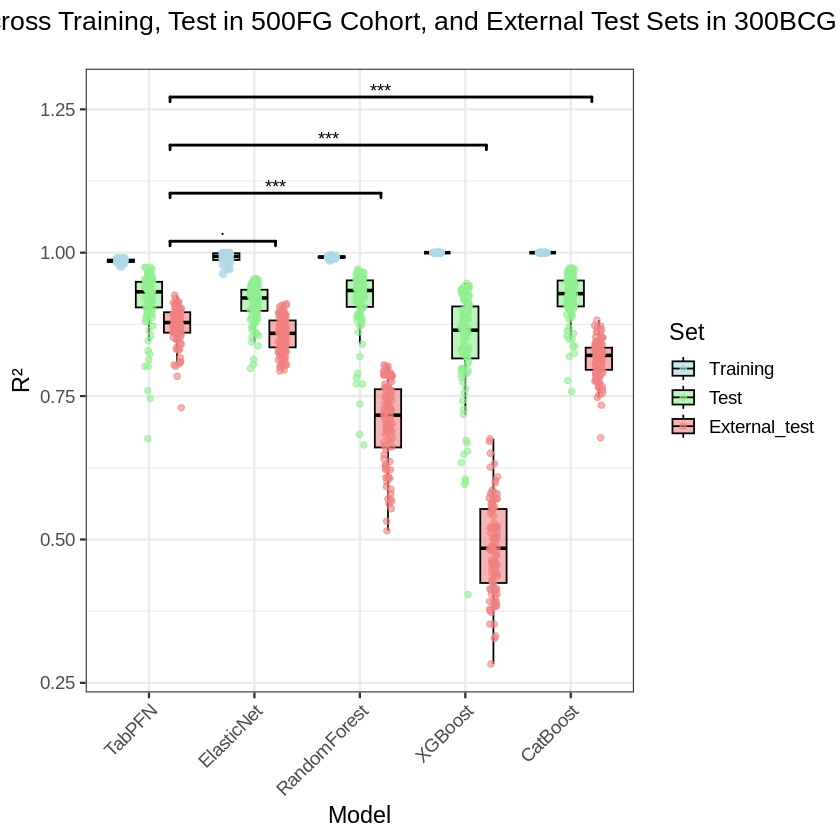

In [14]:
# 筛选 External_test 数据用于显著性检验
external_df <- plot_df_long %>% filter(Set == "External_test")

# 进行ANOVA分析
anova_res_external <- aov(R2 ~ Model, data = external_df)
em_external <- emmeans(anova_res_external, "Model")
contrast_res_external <- contrast(em_external, method = "trt.vs.ctrl", ref = "TabPFN")

# 修改图形代码，添加 External_test 颜色
p <- ggplot(plot_df_long, aes(x = Model, y = R2, fill = Set)) +
  geom_boxplot(
    outlier.shape = NA, 
    position = position_dodge(width = 0.8), 
    alpha = 0.6,
    color = "black"
  ) +
  geom_jitter(
    aes(color = Set), 
    position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8), 
    alpha = 0.6, size = 1.5
  ) +
  # 添加 External_test 颜色
  scale_fill_manual(
    name = "Set", 
    values = c(
      "Training" = "lightblue", 
      "Test" = "lightgreen",
      "External_test" = "lightcoral"
    )
  ) +
  scale_color_manual(
    name = "Set", 
    values = c(
      "Training" = "lightblue", 
      "Test" = "lightgreen",
      "External_test" = "lightcoral"
    )
  ) +
  labs(
    title = "R² Distribution Across Training, Test in 500FG Cohort, and External Test Sets in 300BCG Cohort",
    x = "Model",
    y = "R²"
  ) +
  theme_bw(base_size = 14) +
  theme(
    plot.title = element_text(size = 16, hjust = 0.5, margin = margin(b = 20)),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "right"
  )

# 使用 External_test 的显著性结果
pval_df_external <- as.data.frame(summary(contrast_res_external))
pval_df_external <- pval_df_external %>%
  filter(contrast != "TabPFN - TabPFN") %>%
  separate(contrast, into = c("group2", "group1"), sep = " - ") %>%
  mutate(
    p.adj = p.value,
    y.position = max(plot_df_long$R2) + 0.02 * (1:n()),
    p.adj.signif = symnum(
      p.value,
      corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1),
      symbols = c("***", "**", "*", ".", " ")
    ),
    Set = "External_test"  # 改为 External_test
  )

# 只在 External_test 组加星号
p <- p + stat_pvalue_manual(
  pval_df_external,
  label = "p.adj.signif",
  xmin = "group1",
  xmax = "group2",
  y.position = "y.position",
  group = "Set",
  position = position_nudge(x = 0.2),
  tip.length = 0.01,
  bracket.size = 0.8,
  step.increase = 0.08,
  hide.ns = TRUE
)

print(p)
ggsave("/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/300bcg_four_model_orig_size_methy_spear_tab_with_star.pdf", plot = p, width = 15, height = 8, dpi = 300, units = "in", bg = "white")

In [ ]:
save.image("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison.Rdata")

In [6]:
load("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison.Rdata")

pdf 
  2

pdf 
  2

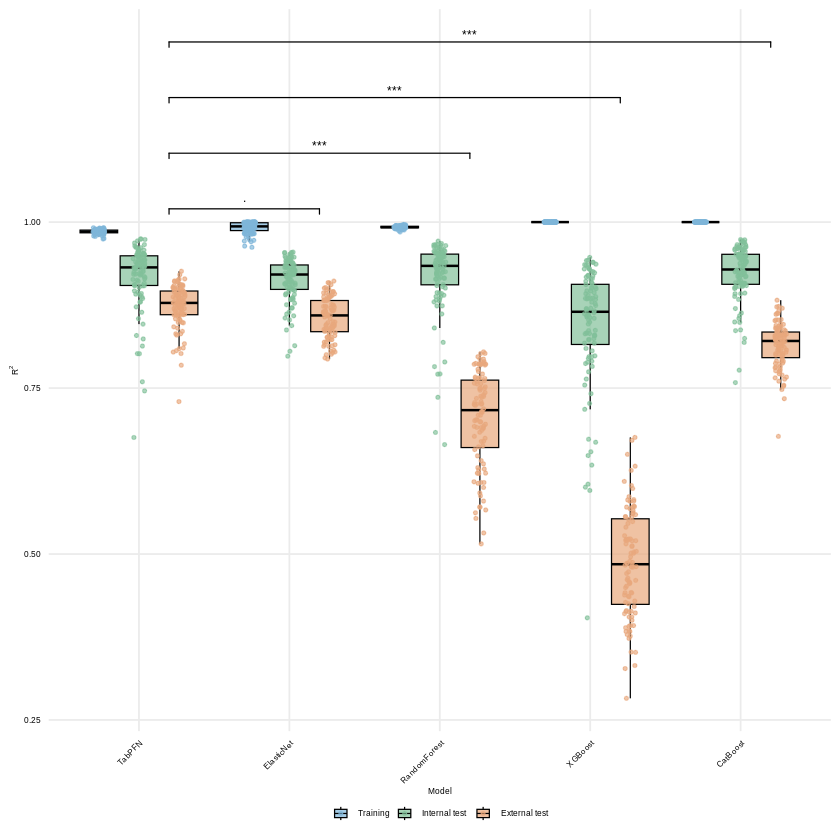

In [14]:
###nature style figure
# 0. Data preparation (requires object 'combined' with R2 columns)
# -----------------------------------------------------------------------------
plot_df <- combined %>%
  select(Model, Iteration, Train_R2, Test_R2, External_R2)

plot_df_long <- plot_df %>%
  pivot_longer(
    cols = c(Train_R2, Test_R2, External_R2),
    names_to = "Set",
    values_to = "R2"
  ) %>%
  mutate(Set = case_when(
    Set == "Train_R2"      ~ "Training",
    Set == "Test_R2"       ~ "Test",
    Set == "External_R2"   ~ "External_test"
  ))

# Ensure Model and Set order
plot_df_long$Model <- factor(
  plot_df_long$Model,
  levels = c("TabPFN", "ElasticNet", "RandomForest", "XGBoost", "CatBoost")
)
plot_df_long$Set <- factor(
  plot_df_long$Set,
  levels = c("Training", "Test", "External_test")
)

# -----------------------------------------------------------------------------
# 1. ANOVA and contrasts (External_test only) — keep your existing logic
# -----------------------------------------------------------------------------
external_df <- plot_df_long %>% filter(Set == "External_test")
anova_res_external <- aov(R2 ~ Model, data = external_df)
em_external <- emmeans(anova_res_external, "Model")
contrast_res_external <- contrast(em_external, method = "trt.vs.ctrl", ref = "TabPFN")

# -----------------------------------------------------------------------------
# 2. Significance table for annotation (External_test)
# -----------------------------------------------------------------------------
pval_df_external <- as.data.frame(summary(contrast_res_external))
pval_df_external <- pval_df_external %>%
  filter(contrast != "TabPFN - TabPFN") %>%
  separate(contrast, into = c("group2", "group1"), sep = " - ") %>%
  mutate(
    p.adj = p.value,
    y.position = max(plot_df_long$R2, na.rm = TRUE) + 0.02 * (1:n()),
    p.adj.signif = symnum(
      p.value,
      corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1),
      symbols = c("***", "**", "*", ".", " ")
    ),
    Set = "External_test"
  )

# -----------------------------------------------------------------------------
# 3. Nature-style settings (same as reference script)
# -----------------------------------------------------------------------------
# Font: 5–7 pt sans-serif — use same sizes for single and double column
# so that when figures are combined, text size is consistent.
axis_text_pt <- 5
axis_title_pt <- 5
legend_text_pt <- 5

# Softer Nature-style colors (Training, Test, External_test)
# col_training    <- "#5B7FA6"   # soft blue
# col_test        <- "#6FAF8E"   # soft sage green
# col_external    <- "#C97A4A"   # soft coral
col_training    <- "#7EB6D9"   # soft blue
col_test        <- "#82C09A"   # soft sage green
col_external    <- "#E8A87C"   # soft coral
fill_values <- c(
  "Training"     = col_training,
  "Test"         = col_test,
  "External_test" = col_external
)
# Legend labels (data levels unchanged; only display text)
legend_labels <- c(
  "Training"     = "Training",
  "Test"         = "Internal test",
  "External_test" = "External test"
)

# -----------------------------------------------------------------------------
# 4. Build the plot (no title; title goes in figure legend)
# -----------------------------------------------------------------------------
p <- ggplot(plot_df_long, aes(x = Model, y = R2, fill = Set)) +
  geom_boxplot(
    outlier.shape = NA,
    position = position_dodge(width = 0.8),
    alpha = 0.7,
    color = "black",
    linewidth = 0.35
  ) +
  geom_jitter(
    aes(color = Set),
    position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8),
    alpha = 0.7,
    size = 0.8
  ) +
  scale_fill_manual(name = "Set", values = fill_values, labels = legend_labels) +
  scale_color_manual(name = "Set", values = fill_values, labels = legend_labels) +
  scale_y_continuous(breaks = seq(0, 1, 0.25)) +
  labs(x = "Model", y = expression(R^2)) +
  theme_minimal(base_family = "sans") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
    axis.text.y = element_text(size = axis_text_pt, colour = "black"),
    axis.title  = element_text(size = axis_title_pt, colour = "black"),
    legend.text = element_text(size = legend_text_pt, colour = "black"),
    legend.title = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  stat_pvalue_manual(
    pval_df_external,
    label = "p.adj.signif",
    xmin = "group1",
    xmax = "group2",
    y.position = "y.position",
    group = "Set",
    position = position_nudge(x = 0.2),
    tip.length = 0.01,
    bracket.size = 0.35,
    step.increase = 0.08,
    hide.ns = TRUE,
    size = 2.5  # annotation size, scale with pt
  )


# -----------------------------------------------------------------------------
# 5. Save double-column (183 mm) and single-column (89 mm)
# Same font sizes in both → text matches when panels are combined.
# -----------------------------------------------------------------------------
# Double column: 183 mm × 80 mm
fig_double_w_mm <- 183
fig_double_h_mm <- 80
pdf("/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/300bcg_four_model_orig_size_methy_spear_double_column2.pdf",
    width = fig_double_w_mm / 25.4, height = fig_double_h_mm / 25.4,
    useDingbats = FALSE)
print(p)
dev.off()

# Single column: 89 mm width; height proportional to keep aspect
fig_single_w_mm <- 62
fig_single_h_mm <- 60
build_plot <- function(box_linewidth = 0.35, jitter_size = 0.8, bracket_size = 0.35,
                       annot_size = 2.5) {
  ggplot(plot_df_long, aes(x = Model, y = R2, fill = Set)) +
    geom_boxplot(
      outlier.shape = NA,
      position = position_dodge(width = 0.8),
      alpha = 0.7,
      color = "black",
      linewidth = box_linewidth
    ) +
    geom_jitter(
      aes(color = Set),
      position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8),
      alpha = 0.65,
      size = jitter_size
    ) +
    scale_fill_manual(name = "Set", values = fill_values, labels = legend_labels) +
    scale_color_manual(name = "Set", values = fill_values, labels = legend_labels) +
    scale_y_continuous(breaks = seq(0, 1, 0.25)) +
    labs(x = "Model", y = expression(R^2)) +
    theme_minimal(base_family = "sans") +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
      axis.text.y = element_text(size = axis_text_pt, colour = "black"),
      axis.title  = element_text(size = axis_title_pt, colour = "black"),
      legend.text = element_text(size = legend_text_pt, colour = "black"),
       legend.position = "bottom",
     legend.direction = "horizontal",
     legend.key.size = unit(0.35, "cm"),
     legend.box.spacing = unit(0, "cm"),
      legend.title = element_blank(),
      panel.grid.minor = element_blank()
    ) +
    stat_pvalue_manual(
      pval_df_external,
      label = "p.adj.signif",
      xmin = "group1",
      xmax = "group2",
      y.position = "y.position",
      group = "Set",
      position = position_nudge(x = 0.2),
      tip.length = 0.01,
      bracket.size = bracket_size,
      step.increase = 0.08,
      hide.ns = TRUE,
      size = annot_size
    )
}
p <- build_plot(box_linewidth = 0.35, jitter_size = 0.8, bracket_size = 0.35, annot_size = 2.5)

p_single <- build_plot(box_linewidth = 0.22, jitter_size = 0.45, bracket_size = 0.22, annot_size = 2)
pdf("/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/300bcg_four_model_orig_size_methy_spear_single_column2.pdf",
    width = fig_single_w_mm / 25.4, height = fig_single_h_mm / 25.4,
    useDingbats = FALSE)
print(p)
dev.off()

print(p)

# A tibble: 4 × 8
  contrast         group1 group2        p    p.adj y.position p.adj.signif Set  
  <chr>            <chr>  <chr>     <dbl>    <dbl>      <dbl> <noquote>    <chr>
1 TabPFN - Elasti… TabPFN Elast… 3.61e-17 3.61e-17       1.02 ***          Exte…
2 TabPFN - Random… TabPFN Rando… 1.74e-43 2.31e-43       1.04 ***          Exte…
3 TabPFN - XGBoost TabPFN XGBoo… 5.68e-55 2.27e-54       1.06 ***          Exte…
4 TabPFN - CatBoo… TabPFN CatBo… 9.38e-45 1.88e-44       1.08 ***          Exte…


pdf 
  2

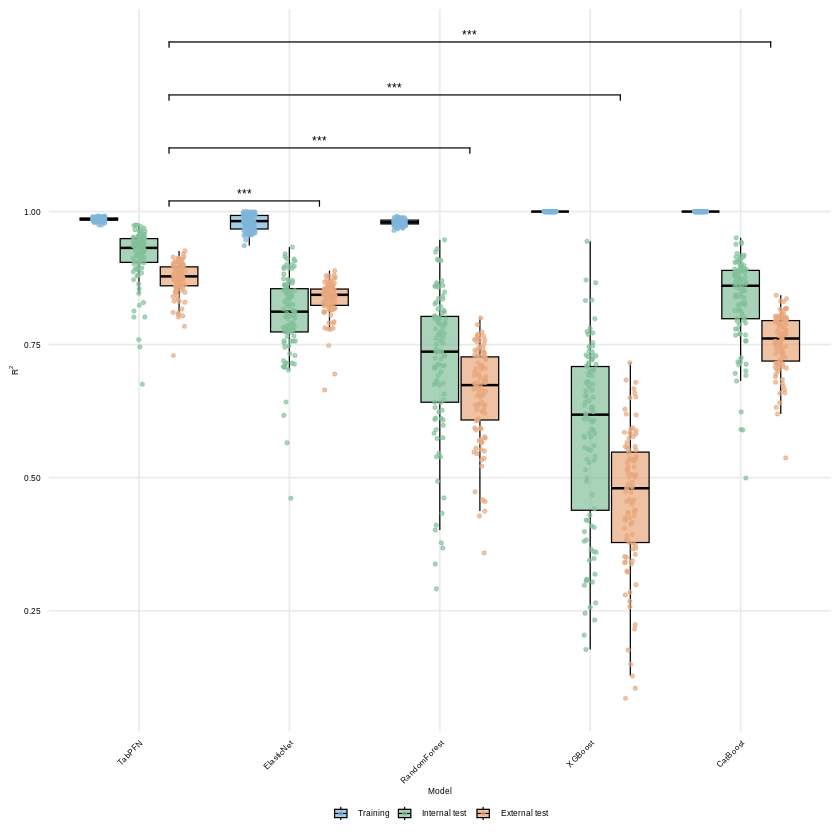

In [19]:
###nature style figure ###t-test
# 0. Data preparation (requires object 'combined' with R2 columns)
# -----------------------------------------------------------------------------
plot_df <- combined %>%
  select(Model, Iteration, Train_R2, Test_R2, External_R2)

plot_df_long <- plot_df %>%
  pivot_longer(
    cols = c(Train_R2, Test_R2, External_R2),
    names_to = "Set",
    values_to = "R2"
  ) %>%
  mutate(Set = case_when(
    Set == "Train_R2"      ~ "Training",
    Set == "Test_R2"       ~ "Test",
    Set == "External_R2"   ~ "External_test"
  ))

# Ensure Model and Set order
plot_df_long$Model <- factor(
  plot_df_long$Model,
  levels = c("TabPFN", "ElasticNet", "RandomForest", "XGBoost", "CatBoost")
)
plot_df_long$Set <- factor(
  plot_df_long$Set,
  levels = c("Training", "Test", "External_test")
)

# -----------------------------------------------------------------------------
# 1. Paired t-tests (External_test only): TabPFN vs each other model, paired by Iteration
# -----------------------------------------------------------------------------
external_df <- plot_df_long %>% filter(Set == "External_test")
wide_external <- external_df %>%
  select(Iteration, Model, R2) %>%
  distinct() %>%
  pivot_wider(names_from = Model, values_from = R2)
others <- setdiff(names(wide_external), c("Iteration", "TabPFN"))
pval_df_external <- map_dfr(others, function(m) {
  d <- wide_external %>% select(Iteration, TabPFN, all_of(m)) %>% drop_na()
  tt <- t.test(d$TabPFN, d[[m]], paired = TRUE)
  tibble(
    contrast = paste0("TabPFN - ", m),
    group1 = "TabPFN",
    group2 = m,
    p = tt$p.value
  )
}) %>%
  mutate(
    p.adj = p.adjust(p, method = "BH"),
    y.position = max(plot_df_long$R2, na.rm = TRUE) + 0.02 * (1:n()),
    p.adj.signif = symnum(
      p.adj,
      corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1),
      symbols = c("***", "**", "*", ".", " ")
    ),
    Set = "External_test"
  )
print(pval_df_external)
# -----------------------------------------------------------------------------
# 3. Nature-style settings (same as reference script)
# -----------------------------------------------------------------------------
# Font: 5–7 pt sans-serif — use same sizes for single and double column
# so that when figures are combined, text size is consistent.
axis_text_pt <- 5
axis_title_pt <- 5
legend_text_pt <- 5

# Softer Nature-style colors (Training, Test, External_test)
# col_training    <- "#5B7FA6"   # soft blue
# col_test        <- "#6FAF8E"   # soft sage green
# col_external    <- "#C97A4A"   # soft coral
# col_training    <- "#7EB6D9"   # soft blue
# col_test        <- "#82C09A"   # soft sage green
# col_external    <- "#E8A87C"   # soft coral
col_300bcg <- "#E8A8A8"   # soft rose / muted red-pink
col_bcg    <- "#A8C4C4"   # soft blue-green (still calm, same “chalk” feel)
col_hmp2   <- "#E8A87C"   # keep: soft coral
fill_values <- c(
  "Training"     = col_training,
  "Test"         = col_test,
  "External_test" = col_external
)
# Legend labels (data levels unchanged; only display text)
legend_labels <- c(
  "Training"     = "Training",
  "Test"         = "Internal test",
  "External_test" = "External test"
)

# -----------------------------------------------------------------------------
# 4. Build the plot (no title; title goes in figure legend)
# -----------------------------------------------------------------------------
p <- ggplot(plot_df_long, aes(x = Model, y = R2, fill = Set)) +
  geom_boxplot(
    outlier.shape = NA,
    position = position_dodge(width = 0.8),
    alpha = 0.7,
    color = "black",
    linewidth = 0.35
  ) +
  geom_jitter(
    aes(color = Set),
    position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8),
    alpha = 0.7,
    size = 0.8
  ) +
  scale_fill_manual(name = "Set", values = fill_values, labels = legend_labels) +
  scale_color_manual(name = "Set", values = fill_values, labels = legend_labels) +
  scale_y_continuous(breaks = seq(0, 1, 0.25)) +
  labs(x = "Model", y = expression(R^2)) +
  theme_minimal(base_family = "sans") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
    axis.text.y = element_text(size = axis_text_pt, colour = "black"),
    axis.title  = element_text(size = axis_title_pt, colour = "black"),
    legend.text = element_text(size = legend_text_pt, colour = "black"),
    legend.title = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  stat_pvalue_manual(
    pval_df_external,
    label = "p.adj.signif",
    xmin = "group1",
    xmax = "group2",
    y.position = "y.position",
    group = "Set",
    position = position_nudge(x = 0.2),
    tip.length = 0.01,
    bracket.size = 0.35,
    step.increase = 0.08,
    hide.ns = TRUE,
    size = 2.5  # annotation size, scale with pt
  )


# -----------------------------------------------------------------------------
# Single column: 89 mm width; height proportional to keep aspect
fig_single_w_mm <- 62
fig_single_h_mm <- 60
build_plot <- function(box_linewidth = 0.35, jitter_size = 0.8, bracket_size = 0.35,
                       annot_size = 2.5) {
  ggplot(plot_df_long, aes(x = Model, y = R2, fill = Set)) +
    geom_boxplot(
      outlier.shape = NA,
      position = position_dodge(width = 0.8),
      alpha = 0.7,
      color = "black",
      linewidth = box_linewidth
    ) +
    geom_jitter(
      aes(color = Set),
      position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8),
      alpha = 0.65,
      size = jitter_size
    ) +
    scale_fill_manual(name = "Set", values = fill_values, labels = legend_labels) +
    scale_color_manual(name = "Set", values = fill_values, labels = legend_labels) +
    scale_y_continuous(breaks = seq(0, 1, 0.25)) +
    labs(x = "Model", y = expression(R^2)) +
    theme_minimal(base_family = "sans") +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
      axis.text.y = element_text(size = axis_text_pt, colour = "black"),
      axis.title  = element_text(size = axis_title_pt, colour = "black"),
      legend.text = element_text(size = legend_text_pt, colour = "black"),
       legend.position = "bottom",
     legend.direction = "horizontal",
     legend.key.size = unit(0.35, "cm"),
     legend.box.spacing = unit(0, "cm"),
      legend.title = element_blank(),
      panel.grid.minor = element_blank()
    ) +
    stat_pvalue_manual(
      pval_df_external,
      label = "p.adj.signif",
      xmin = "group1",
      xmax = "group2",
      y.position = "y.position",
      group = "Set",
      position = position_nudge(x = 0.2),
      tip.length = 0.01,
      bracket.size = bracket_size,
      step.increase = 0.08,
      hide.ns = TRUE,
      size = annot_size
    )
}
p <- build_plot(box_linewidth = 0.35, jitter_size = 0.8, bracket_size = 0.35, annot_size = 2.5)

p_single <- build_plot(box_linewidth = 0.22, jitter_size = 0.45, bracket_size = 0.22, annot_size = 2)
pdf("/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/300bcg_four_model_orig_size_methy_spear_single_column_ttest.pdf",
    width = fig_single_w_mm / 25.4, height = fig_single_h_mm / 25.4,
    useDingbats = FALSE)
print(p)
dev.off()

print(p)

In [7]:
save.image("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison_ttest_nature.Rdata")

In [7]:
##load results from all cohorts
bcg_prime_results <- read.csv("/vol/projects/yzhang/BCG_prime/05_multi-omics_model/output/prime_model_results_top125.csv")    
hmp2_results <- read.csv("/vol/projects/yzhang/500FG_aging/input/prediction/foundation_model/USA_aging_input/process/result/top100/model_results_usa_top100.csv")
head(bcg_prime_results)
head(hmp2_results)

,Model,Iteration,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MSE,Test_MSE
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ElasticNet,1,0.9262466,0.6302937,1.693997,3.317925,2.869627,11.008628
2,ElasticNet,2,0.9128079,0.6539147,1.937576,2.756517,3.754199,7.598385
3,ElasticNet,3,0.9394081,0.6375826,1.483040,3.717667,2.199408,13.821045
4,ElasticNet,4,0.9096029,0.7001457,1.876446,3.112410,3.521050,9.687098
5,ElasticNet,5,0.9020688,0.5100948,2.010925,3.791697,4.043821,14.376965
6,ElasticNet,6,0.8642141,0.6720948,2.359021,3.138366,5.564982,9.849342


,Model,Iteration,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MSE,Test_MSE
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ElasticNet,1,0.9665396,0.23588333,2.497629,8.952917,6.238148,80.15472
2,ElasticNet,2,0.9494954,0.16356659,3.208188,9.654739,10.292468,93.21398
3,ElasticNet,3,0.9371559,0.03292181,3.497132,9.049227,12.229931,81.88850
4,ElasticNet,4,0.8831001,0.60728317,4.371125,9.111450,19.106736,83.01851
5,ElasticNet,5,0.7523613,0.16458090,6.310767,8.568229,39.825780,73.41454
6,ElasticNet,6,0.9303434,0.52115508,3.758574,6.518845,14.126876,42.49534


# A tibble: 12 × 6
   Cohort    group1 group2              p    p.adj p.adj.signif
   <fct>     <fct>  <fct>           <dbl>    <dbl> <noquote>   
 1 300BCG    TabPFN ElasticNet   5.02e-34 1.00e-33 ***         
 2 300BCG    TabPFN RandomForest 5.21e-31 6.95e-31 ***         
 3 300BCG    TabPFN XGBoost      2.57e-39 1.03e-38 ***         
 4 300BCG    TabPFN CatBoost     1.75e-26 1.75e-26 ***         
 5 BCG_Prime TabPFN ElasticNet   4.52e- 3 4.52e- 3 **          
 6 BCG_Prime TabPFN RandomForest 6.34e-19 1.27e-18 ***         
 7 BCG_Prime TabPFN XGBoost      7.51e-38 3.00e-37 ***         
 8 BCG_Prime TabPFN CatBoost     1.22e- 4 1.63e- 4 ***         
 9 HMP2      TabPFN ElasticNet   1.70e-16 3.40e-16 ***         
10 HMP2      TabPFN RandomForest 2.59e- 4 3.46e- 4 ***         
11 HMP2      TabPFN XGBoost      2.70e-28 1.08e-27 ***         
12 HMP2      TabPFN CatBoost     8.93e- 4 8.93e- 4 ***         


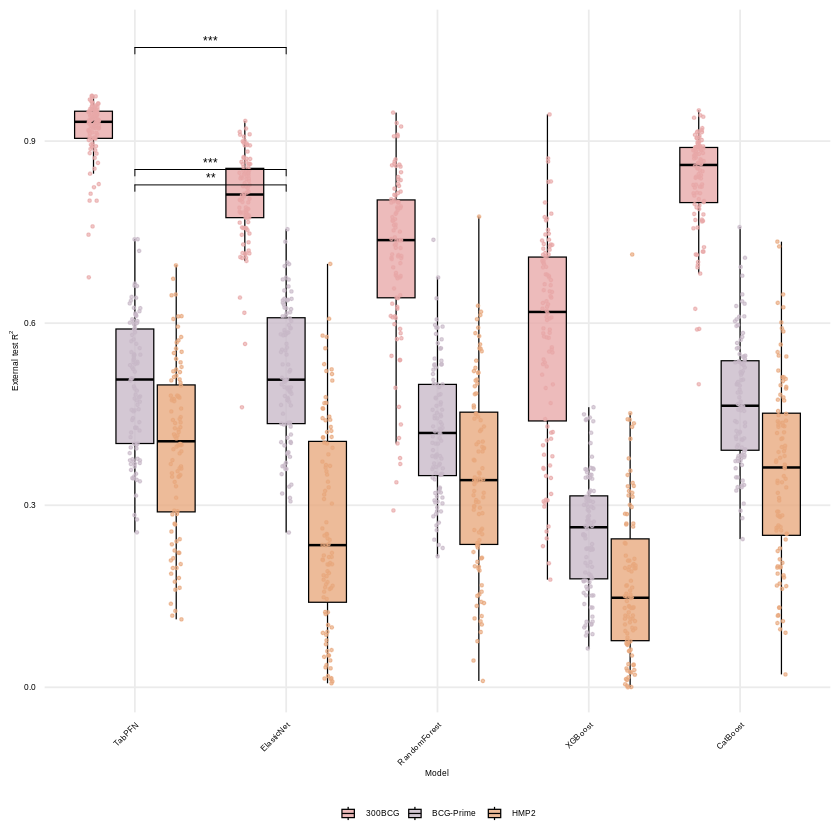

In [28]:
METRIC <- "Test_R2"  # or "External_R2"
stopifnot(
  exists("tabpfn"), is.data.frame(tabpfn), "Model" %in% names(tabpfn),
  exists("bcg_prime_results"), is.data.frame(bcg_prime_results), "Model" %in% names(bcg_prime_results),
  exists("hmp2_results"), is.data.frame(hmp2_results), "Model" %in% names(hmp2_results)
)
# 300BCG: use full `tabpfn` as in the original notebook (no rbind with four_orig)
combined_300bcg <- tabpfn %>% mutate(Cohort = "300BCG")
combined_bcg  <- bcg_prime_results %>% mutate(Cohort = "BCG_Prime")
combined_hmp2 <- hmp2_results %>% mutate(Cohort = "HMP2")
combined_all <- bind_rows(combined_300bcg, combined_bcg, combined_hmp2)
combined <- combined_300bcg
plot_df <- combined_all %>%
  select(Cohort, Model, Iteration, Test_R2, External_R2) %>%
  mutate(
    Cohort = factor(Cohort, levels = c("300BCG", "BCG_Prime", "HMP2")),
    Model = factor(
      Model,
      levels = c("TabPFN", "ElasticNet", "RandomForest", "XGBoost", "CatBoost")
    )
  )
wide_by_cohort <- plot_df %>%
  select(Cohort, Iteration, Model, value = all_of(METRIC)) %>%
  distinct() %>%
  pivot_wider(names_from = Model, values_from = value)
pval_df <- wide_by_cohort %>%
  group_split(Cohort) %>%
  map_dfr(function(w) {
    coh <- as.character(unique(w$Cohort))
    others <- setdiff(names(w), c("Cohort", "Iteration", "TabPFN"))
    map_dfr(others, function(m) {
      d <- w %>% select(Iteration, TabPFN, all_of(m)) %>% drop_na()
      if (nrow(d) < 2) {
        return(tibble(Cohort = coh, group1 = "TabPFN", group2 = m, p = NA_real_))
      }
      tt <- t.test(d$TabPFN, d[[m]], paired = TRUE)
      tibble(Cohort = coh, group1 = "TabPFN", group2 = m, p = tt$p.value)
    })
  }) %>%
  group_by(Cohort) %>%
  mutate(p.adj = p.adjust(p, method = "BH")) %>%
  ungroup() %>%
  mutate(
    group1 = factor(group1, levels = levels(plot_df$Model)),
    group2 = factor(group2, levels = levels(plot_df$Model)),
    Cohort = factor(Cohort, levels = levels(plot_df$Cohort)),
    p.adj.signif = symnum(
      p.adj, corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1),
      symbols = c("***", "**", "*", ".", "ns")
    )
  )
print(pval_df)

# --- Brackets for ggpubr: only TabPFN vs ElasticNet on the figure (remove filter() for all contrasts) ---
rng <- plot_df %>%
  group_by(Cohort) %>%
  summarise(
    ymax = max(.data[[METRIC]], na.rm = TRUE),
    span = pmax(max(.data[[METRIC]], na.rm = TRUE) - min(.data[[METRIC]], na.rm = TRUE), 1e-6),
    .groups = "drop"
  )
pval_bracket <- pval_df %>%
  filter(as.character(group2) == "ElasticNet") %>%
  left_join(rng, by = "Cohort") %>%
  mutate(y.position = ymax + 0.10 * span)

axis_text_pt <- 5
axis_title_pt <- 5
legend_text_pt <- 5
# col_300bcg <- "#7EB6D9"
# col_bcg    <- "#82C09A"
# col_hmp2   <- "#E8A87C"
col_300bcg <- "#E8A8A8"   # soft rose / muted red-pink
col_bcg    <- "#C8B8C8"    # soft blue-green (still calm, same “chalk” feel)
col_hmp2   <- "#E8A87C"   # keep: soft coral
fill_cohort <- c("300BCG" = col_300bcg, "BCG_Prime" = col_bcg, "HMP2" = col_hmp2)
labels_cohort <- c("300BCG" = "300BCG", "BCG_Prime" = "BCG-Prime", "HMP2" = "HMP2")
ylab_plot <- if (identical(METRIC, "Test_R2")) {
  expression(Test ~ R^2)
} else {
  expression(External ~ test ~ R^2)
}
p <- ggplot(plot_df, aes(x = Model, y = !!sym(METRIC), fill = Cohort)) +
  geom_boxplot(
    outlier.shape = NA,
    position = position_dodge(width = 0.82),
    colour = "black",
    linewidth = 0.35,
    alpha = 0.78
  ) +
  geom_jitter(
    aes(colour = Cohort),
    position = position_jitterdodge(jitter.width = 0.18, dodge.width = 0.82),
    alpha = 0.65,
    size = 0.65,
    show.legend = FALSE
  ) +
  scale_fill_manual(name = "Cohort", values = fill_cohort, labels = labels_cohort) +
  scale_colour_manual(values = fill_cohort, guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0.04, 0.06))) +
  labs(x = "Model", y = expression(External ~ test ~ R^2)) +
  theme_minimal(base_family = "sans") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
    axis.text.y = element_text(size = axis_text_pt, colour = "black"),
    axis.title = element_text(size = axis_title_pt, colour = "black"),
    legend.text = element_text(size = legend_text_pt, colour = "black"),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.key.size = unit(0.35, "cm"),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(colour = "white", fill = NA, linewidth = 0.35)
  )+
  stat_pvalue_manual(
    pval_bracket,
    label = "p.adj.signif",
    xmin = "group1",
    xmax = "group2",
    y.position = "y.position",
    group = "Cohort",
    tip.length = 0.01,
    bracket.size = 0.28,
    hide.ns = TRUE,
    size = 2.5
  )

fig_w_mm <- 170
fig_h_mm <- 100
out_pdf <- sprintf(
  "/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/%s_by_model_three_cohorts_dodge.pdf",
  METRIC
)
ggsave(
  filename = out_pdf,
  plot = p,
  width = fig_w_mm / 25.4,
  height = fig_h_mm / 25.4,
  device = "pdf",
  useDingbats = FALSE
)
print(p)

Warning message in geom_signif(data = brack_draw, inherit.aes = FALSE, aes(xmin = xmin, :
“Ignoring unknown aesthetics: xmin, xmax, annotations, and y_position”
Don't know how to automatically pick scale for object of type <noquote>. Defaulting to continuous.
Warning message:
“The following aesthetics were dropped during statistical transformation: xmin, xmax, and y_position.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”


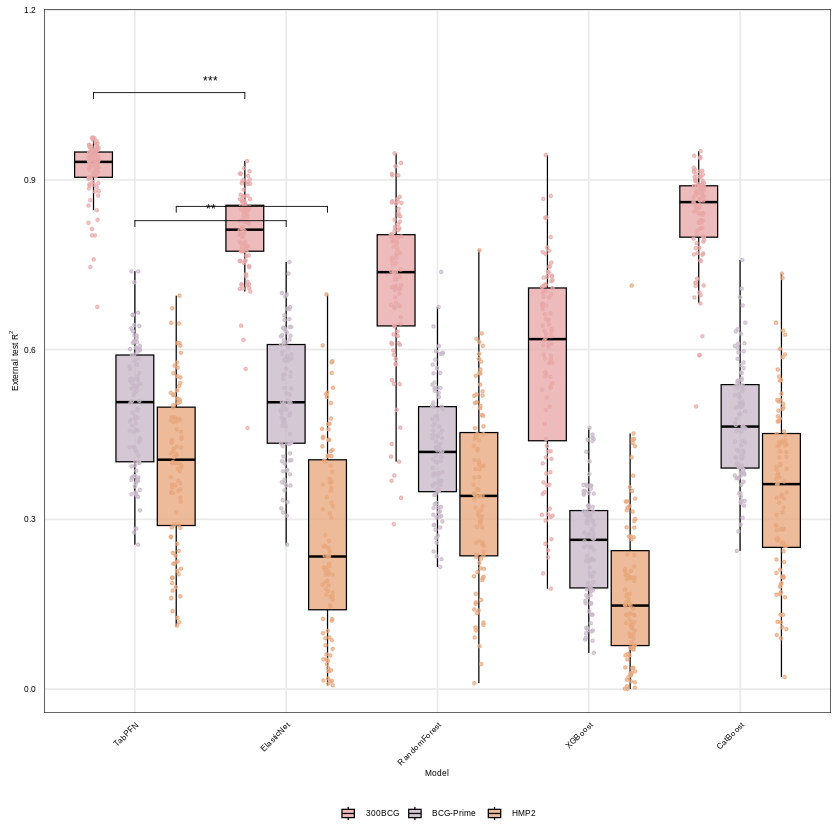

In [30]:
library(ggsignif)

library(ggsignif)

dodge_w <- 0.82
n_c <- nlevels(plot_df$Cohort)

# x 坐标与 ggplot position_dodge(width) 一致：每个 Model 上 cohort k 的中心
coh_x <- function(model_chr, cohort_f) {
  xm <- as.numeric(factor(model_chr, levels = levels(plot_df$Model)))
  cn <- as.numeric(cohort_f)  # 1..n_c
  xm + (cn - (n_c + 1) / 2) * (dodge_w / n_c)
}

brack_draw <- pval_bracket %>%
  mutate(
    xmin = coh_x("TabPFN", Cohort),
    xmax = coh_x("ElasticNet", Cohort)
  )

p <- ggplot(plot_df, aes(x = Model, y = !!sym(METRIC), fill = Cohort)) +
  geom_boxplot(
    outlier.shape = NA,
    position = position_dodge(width = dodge_w),
    colour = "black",
    linewidth = 0.35,
    alpha = 0.78
  ) +
  geom_jitter(
    aes(colour = Cohort),
    position = position_jitterdodge(jitter.width = 0.18, dodge.width = dodge_w),
    alpha = 0.65,
    size = 0.65,
    show.legend = FALSE
  ) +
  scale_fill_manual(name = "Cohort", values = fill_cohort, labels = labels_cohort) +
  scale_colour_manual(values = fill_cohort, guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0.04, 0.14))) +
  labs(x = "Model", y = expression(External ~ test ~ R^2)) +
  theme_minimal(base_family = "sans") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
    axis.text.y = element_text(size = axis_text_pt, colour = "black"),
    axis.title = element_text(size = axis_title_pt, colour = "black"),
    legend.text = element_text(size = legend_text_pt, colour = "black"),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.key.size = unit(0.35, "cm"),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(colour = "white", fill = NA, linewidth = 0.35)
  ) +
  geom_signif(
    data = brack_draw,
    inherit.aes = FALSE,
    aes(
      xmin = xmin,
      xmax = xmax,
      annotations = p.adj.signif,
      y_position = y.position
    ),
    manual = TRUE,
    tip_length = 0.01,
    textsize = 2.5,
    size = 0.25,
    colour = "black",
    vjust = -0.05
  )

print(p)

# A tibble: 12 × 6
   Cohort    group1 group2              p    p.adj p.adj.signif
   <fct>     <fct>  <fct>           <dbl>    <dbl> <noquote>   
 1 300BCG    TabPFN ElasticNet   5.02e-34 1.00e-33 ***         
 2 300BCG    TabPFN RandomForest 5.21e-31 6.95e-31 ***         
 3 300BCG    TabPFN XGBoost      2.57e-39 1.03e-38 ***         
 4 300BCG    TabPFN CatBoost     1.75e-26 1.75e-26 ***         
 5 BCG_Prime TabPFN ElasticNet   4.52e- 3 4.52e- 3 **          
 6 BCG_Prime TabPFN RandomForest 6.34e-19 1.27e-18 ***         
 7 BCG_Prime TabPFN XGBoost      7.51e-38 3.00e-37 ***         
 8 BCG_Prime TabPFN CatBoost     1.22e- 4 1.63e- 4 ***         
 9 HMP2      TabPFN ElasticNet   1.70e-16 3.40e-16 ***         
10 HMP2      TabPFN RandomForest 2.59e- 4 3.46e- 4 ***         
11 HMP2      TabPFN XGBoost      2.70e-28 1.08e-27 ***         
12 HMP2      TabPFN CatBoost     8.93e- 4 8.93e- 4 ***         


Warning message in geom_signif(data = brack_draw, inherit.aes = FALSE, aes(xmin = xmin, :
“Ignoring unknown aesthetics: xmin, xmax, annotations, and y_position”
Warning message:
“The following aesthetics were dropped during statistical transformation: xmin, xmax, and y_position.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”
Warning message:
“The following aesthetics were dropped during statistical transformation: xmin, xmax, and y_position.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”
Saved:
  /vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/Test_R2_by_model_three_cohorts_dodge_sig_global_bracket.pdf
  /vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/Test_R2_by

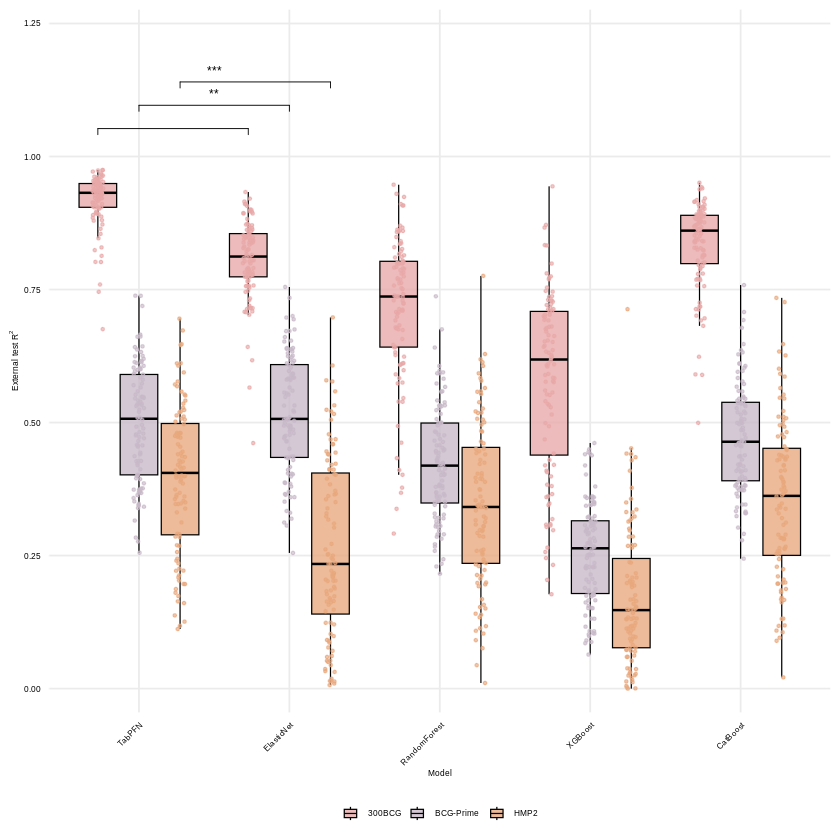

In [41]:
METRIC <- "Test_R2"  # or "External_R2"
stopifnot(
  exists("tabpfn"), is.data.frame(tabpfn), "Model" %in% names(tabpfn),
  exists("bcg_prime_results"), is.data.frame(bcg_prime_results), "Model" %in% names(bcg_prime_results),
  exists("hmp2_results"), is.data.frame(hmp2_results), "Model" %in% names(hmp2_results)
)
combined_300bcg <- tabpfn %>% mutate(Cohort = "300BCG")
combined_bcg  <- bcg_prime_results %>% mutate(Cohort = "BCG_Prime")
combined_hmp2 <- hmp2_results %>% mutate(Cohort = "HMP2")
combined_all <- bind_rows(combined_300bcg, combined_bcg, combined_hmp2)
combined <- combined_300bcg
plot_df <- combined_all %>%
  select(Cohort, Model, Iteration, Test_R2, External_R2) %>%
  mutate(
    Cohort = factor(Cohort, levels = c("300BCG", "BCG_Prime", "HMP2")),
    Model = factor(
      Model,
      levels = c("TabPFN", "ElasticNet", "RandomForest", "XGBoost", "CatBoost")
    )
  )
wide_by_cohort <- plot_df %>%
  select(Cohort, Iteration, Model, value = all_of(METRIC)) %>%
  distinct() %>%
  pivot_wider(names_from = Model, values_from = value)
pval_df <- wide_by_cohort %>%
  group_split(Cohort) %>%
  map_dfr(function(w) {
    coh <- as.character(unique(w$Cohort))
    others <- setdiff(names(w), c("Cohort", "Iteration", "TabPFN"))
    map_dfr(others, function(m) {
      d <- w %>% select(Iteration, TabPFN, all_of(m)) %>% drop_na()
      if (nrow(d) < 2) {
        return(tibble(Cohort = coh, group1 = "TabPFN", group2 = m, p = NA_real_))
      }
      tt <- t.test(d$TabPFN, d[[m]], paired = TRUE)
      tibble(Cohort = coh, group1 = "TabPFN", group2 = m, p = tt$p.value)
    })
  }) %>%
  group_by(Cohort) %>%
  mutate(p.adj = p.adjust(p, method = "BH")) %>%
  ungroup() %>%
  mutate(
    group1 = factor(group1, levels = levels(plot_df$Model)),
    group2 = factor(group2, levels = levels(plot_df$Model)),
    Cohort = factor(Cohort, levels = levels(plot_df$Cohort)),
    p.adj.signif = symnum(
      p.adj,
      corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1),
      symbols = c("***", "**", "*", ".", "ns")
    )
  )
print(pval_df)
# --- Only TabPFN vs ElasticNet on the figure (must define pval_bracket) ---
pval_bracket <- pval_df %>% filter(as.character(group2) == "ElasticNet")
# --- Global max across ALL cohorts × models ---
y_gmax <- max(plot_df[[METRIC]], na.rm = TRUE)
y_gmin <- min(plot_df[[METRIC]], na.rm = TRUE)
span_g <- pmax(y_gmax - y_gmin, 1e-6)
dodge_w <- 0.82
n_c <- nlevels(plot_df$Cohort)
coh_x <- function(model_chr, cohort_f) {
  xm <- as.numeric(factor(model_chr, levels = levels(plot_df$Model)))
  cn <- as.numeric(cohort_f)
  xm + (cn - (n_c + 1) / 2) * (dodge_w / n_c)
}
brack_draw <- pval_bracket %>%
  mutate(
    xmin = coh_x("TabPFN", Cohort),
    xmax = coh_x("ElasticNet", Cohort),
    y.position = y_gmax + span_g * (0.08 + 0.045 * (as.numeric(Cohort) - 1)),
    p.lab = case_when(
      is.na(p.adj) ~ "ns",
      p.adj >= 0.05 ~ "ns",
      TRUE ~ trimws(as.character(p.adj.signif))
    )
  )
axis_text_pt <- 5
axis_title_pt <- 5
legend_text_pt <- 5
col_300bcg <- "#E8A8A8"
col_bcg    <- "#C8B8C8"
col_hmp2   <- "#E8A87C"
fill_cohort <- c("300BCG" = col_300bcg, "BCG_Prime" = col_bcg, "HMP2" = col_hmp2)
labels_cohort <- c("300BCG" = "300BCG", "BCG_Prime" = "BCG-Prime", "HMP2" = "HMP2")
p <- ggplot(plot_df, aes(x = Model, y = !!sym(METRIC), fill = Cohort)) +
  geom_boxplot(
    outlier.shape = NA,
    position = position_dodge(width = dodge_w),
    colour = "black",
    linewidth = 0.35,
    alpha = 0.78
  ) +
  geom_jitter(
    aes(colour = Cohort),
    position = position_jitterdodge(jitter.width = 0.18, dodge.width = dodge_w),
    alpha = 0.65,
    size = 0.65,
    show.legend = FALSE
  ) +
  scale_fill_manual(name = "Cohort", values = fill_cohort, labels = labels_cohort) +
  scale_colour_manual(values = fill_cohort, guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0.04, 0.12))) +
  labs(x = "Model", y = expression(External ~ test ~ R^2)) +
  theme_minimal(base_family = "sans") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
    axis.text.y = element_text(size = axis_text_pt, colour = "black"),
    axis.title = element_text(size = axis_title_pt, colour = "black"),
    legend.text = element_text(size = legend_text_pt, colour = "black"),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.key.size = unit(0.35, "cm"),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(colour = "white", fill = NA, linewidth = 0.35)
  ) +
  geom_signif(
    data = brack_draw,
    inherit.aes = FALSE,
    aes(
      xmin = xmin,
      xmax = xmax,
      annotations = p.lab,
      y_position = y.position
    ),
    manual = TRUE,
    tip_length = 0.01,
    textsize = 2.5,
    size = 0.25,
    colour = "black"
  )
out_dir <- "/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
fig_w_mm <- 170
fig_h_mm <- 100
pdf_path <- file.path(out_dir, sprintf("%s_by_model_three_cohorts_dodge_sig_global_bracket.pdf", METRIC))
csv_path <- file.path(out_dir, sprintf("%s_by_model_three_cohorts_paired_tests.csv", METRIC))
ggsave(
  filename = pdf_path,
  plot = p,
  width = fig_w_mm / 25.4,
  height = fig_h_mm / 25.4,
  device = "pdf",
  useDingbats = FALSE
)
utils::write.csv(pval_df, csv_path, row.names = FALSE)
print(p)
message("Saved:\n  ", pdf_path, "\n  ", csv_path)

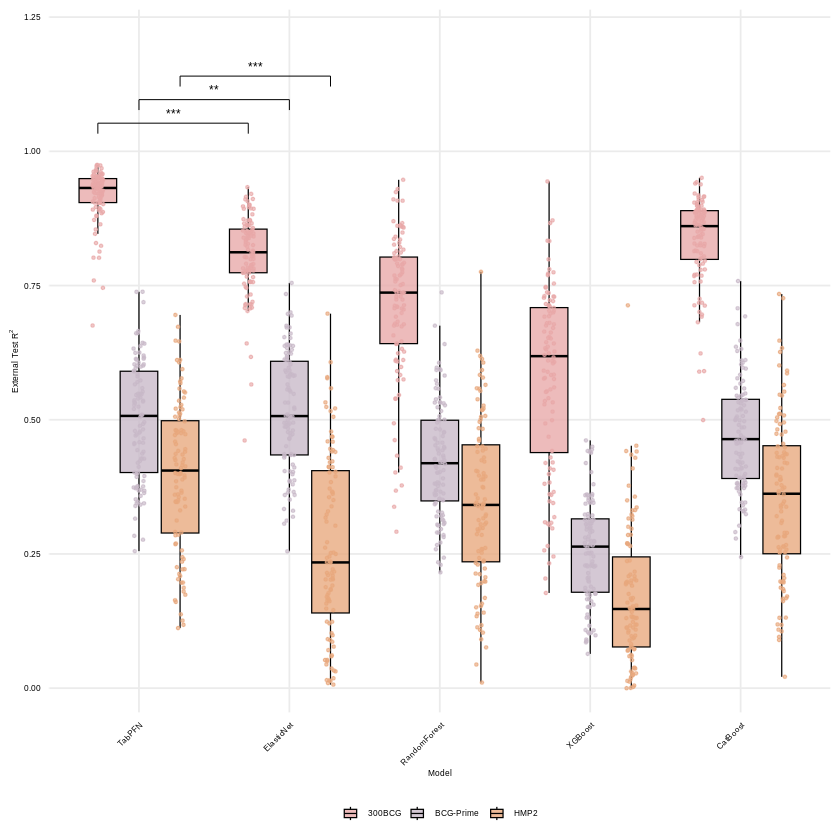

In [46]:
# brack_draw 已有：xmin, xmax, y.position, p.lab
tick_h <- 0.02 * span_g  # 竖钩长度，可按图调

p <- ggplot(plot_df, aes(x = Model, y = !!sym(METRIC), fill = Cohort)) +
  geom_boxplot(
    outlier.shape = NA,
    position = position_dodge(width = dodge_w),
    colour = "black",
    linewidth = 0.35,
    alpha = 0.78
  ) +
  geom_jitter(
    aes(colour = Cohort),
    position = position_jitterdodge(jitter.width = 0.18, dodge.width = dodge_w),
    alpha = 0.65,
    size = 0.65,
    show.legend = FALSE
  ) +
  scale_fill_manual(name = "Cohort", values = fill_cohort, labels = labels_cohort) +
  scale_colour_manual(values = fill_cohort, guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0.04, 0.10))) +
  labs(x = "Model", y = expression(External ~ Test ~ R^2)) +
  theme_minimal(base_family = "sans") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
    axis.text.y = element_text(size = axis_text_pt, colour = "black"),
    axis.title = element_text(size = axis_title_pt, colour = "black"),
    legend.text = element_text(size = legend_text_pt, colour = "black"),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.key.size = unit(0.35, "cm"),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(colour = "white", fill = NA, linewidth = 0.35)
  ) +
  # 横线
  geom_segment(
    data = brack_draw,
    inherit.aes = FALSE,
    aes(x = xmin, xend = xmax, y = y.position, yend = y.position),
    linewidth = 0.28,
    colour = "black"
  ) +
  # 左竖
  geom_segment(
    data = brack_draw,
    inherit.aes = FALSE,
    aes(x = xmin, xend = xmin, y = y.position - tick_h, yend = y.position),
    linewidth = 0.28,
    colour = "black"
  ) +
  # 右竖
  geom_segment(
    data = brack_draw,
    inherit.aes = FALSE,
    aes(x = xmax, xend = xmax, y = y.position - tick_h, yend = y.position),
    linewidth = 0.28,
    colour = "black"
  ) +
  # 星号 / ns
  geom_text(
    data = brack_draw,
    inherit.aes = FALSE,
    aes(x = (xmin + xmax) / 2, y = y.position + 0.01 * span_g, label = p.lab),
    size = 2.5,
    colour = "black",
    vjust = 0
  )

print(p)

out_dir <- "/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
fig_w_mm <- 170
fig_h_mm <- 100
pdf_path <- file.path(out_dir, sprintf("%s_by_model_three_cohorts_dodge_sig_global_bracket.pdf", METRIC))
csv_path <- file.path(out_dir, sprintf("%s_by_model_three_cohorts_paired_tests.csv", METRIC))
ggsave(
  filename = pdf_path,
  plot = p,
  width = fig_w_mm / 25.4,
  height = fig_h_mm / 25.4,
  device = "pdf",
  useDingbats = FALSE
)

# A tibble: 16 × 9
   Panel     group1 group2        p    p.adj p.adj.signif  ymax  span y.position
   <fct>     <fct>  <fct>     <dbl>    <dbl> <noquote>    <dbl> <dbl>      <dbl>
 1 500FG     TabPFN Elast… 5.02e-34 1.00e-33 ***          0.974 0.797      1.05 
 2 500FG     TabPFN Rando… 5.21e-31 6.95e-31 ***          0.974 0.797      1.08 
 3 500FG     TabPFN XGBoo… 2.57e-39 1.03e-38 ***          0.974 0.797      1.11 
 4 500FG     TabPFN CatBo… 1.75e-26 1.75e-26 ***          0.974 0.797      1.14 
 5 300BCG    TabPFN Elast… 3.61e-17 3.61e-17 ***          0.926 0.840      1.00 
 6 300BCG    TabPFN Rando… 1.74e-43 2.31e-43 ***          0.926 0.840      1.04 
 7 300BCG    TabPFN XGBoo… 5.68e-55 2.27e-54 ***          0.926 0.840      1.07 
 8 300BCG    TabPFN CatBo… 9.38e-45 1.88e-44 ***          0.926 0.840      1.10 
 9 BCG-Prime TabPFN Elast… 4.52e- 3 4.52e- 3 **           0.758 0.694      0.821
10 BCG-Prime TabPFN Rando… 6.34e-19 1.27e-18 ***          0.758 0.694      0.849
11 BCG-Pr

Saved:
  /vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/validation_four_panels_nature.pdf
  /vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/validation_four_panels_paired_ttests.csv



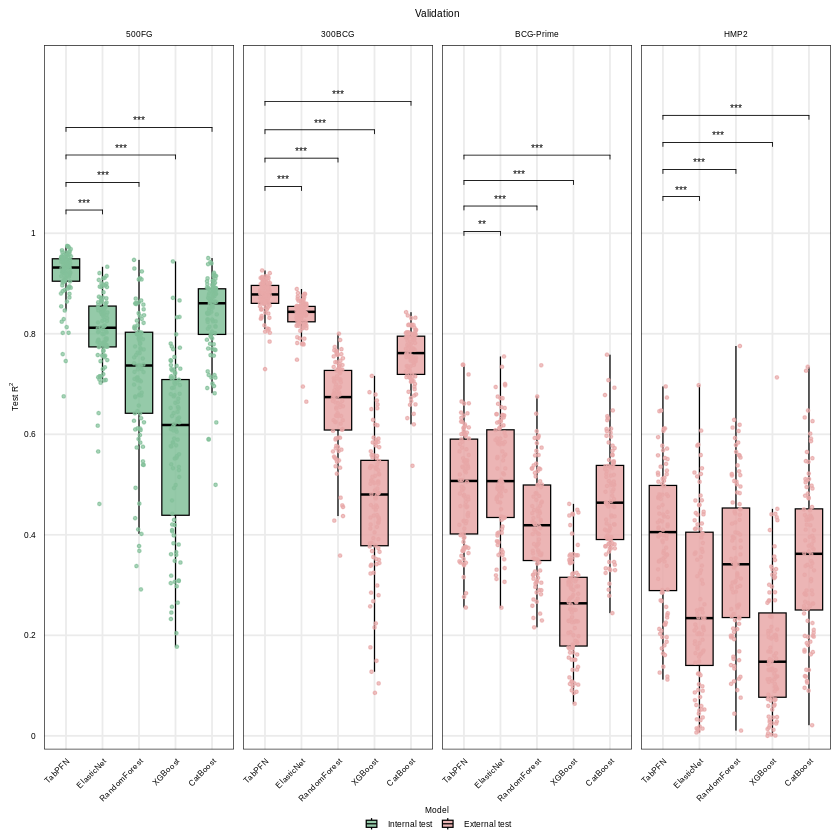

In [21]:
### divided by 4 panel (updated: panel names only + bottom horizontal legend)
model_levels <- c("TabPFN", "ElasticNet", "RandomForest", "XGBoost", "CatBoost")
panel_levels <- c("500FG", "300BCG", "BCG-Prime", "HMP2")

# -------------------------------------------------------------------------
# 1) Build one long table (SetType controls color legend)
# -------------------------------------------------------------------------
plot_df_4panel <- bind_rows(
  tabpfn %>%
    transmute(Panel = "500FG", Model, Iteration, R2 = Test_R2, SetType = "Internal test"),
  tabpfn %>%
    transmute(Panel = "300BCG", Model, Iteration, R2 = External_R2, SetType = "External test"),
  bcg_prime_results %>%
    transmute(Panel = "BCG-Prime", Model, Iteration, R2 = Test_R2, SetType = "External test"),
  hmp2_results %>%
    transmute(Panel = "HMP2", Model, Iteration, R2 = Test_R2, SetType = "External test")
) %>%
  mutate(
    Model = factor(as.character(Model), levels = model_levels),
    Panel = factor(as.character(Panel), levels = panel_levels),
    SetType = factor(SetType, levels = c("Internal test", "External test"))
  ) %>%
  filter(!is.na(R2), Model %in% model_levels, !is.na(Panel))

# -------------------------------------------------------------------------
# 2) Paired t-tests: TabPFN vs each other model within each panel
# -------------------------------------------------------------------------
wide_by_panel <- plot_df_4panel %>%
  distinct(Panel, Iteration, Model, R2) %>%
  pivot_wider(names_from = Model, values_from = R2)

pval_df_4panel <- wide_by_panel %>%
  group_split(Panel) %>%
  map_dfr(function(w) {
    pn <- as.character(unique(w$Panel))
    others <- setdiff(names(w), c("Panel", "Iteration", "TabPFN"))
    map_dfr(others, function(m) {
      d <- w %>% select(Iteration, TabPFN, all_of(m)) %>% drop_na()
      if (nrow(d) < 2) {
        return(tibble(Panel = pn, group1 = "TabPFN", group2 = m, p = NA_real_))
      }
      tt <- t.test(d$TabPFN, d[[m]], paired = TRUE)
      tibble(Panel = pn, group1 = "TabPFN", group2 = m, p = tt$p.value)
    })
  }) %>%
  group_by(Panel) %>%
  mutate(p.adj = p.adjust(p, method = "BH")) %>%
  ungroup() %>%
  mutate(
    Panel = factor(as.character(Panel), levels = panel_levels),
    group1 = factor(group1, levels = model_levels),
    group2 = factor(group2, levels = model_levels),
    p.adj.signif = symnum(
      p.adj,
      corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1),
      symbols = c("***", "**", "*", ".", "ns")
    )
  )

# y-position per panel
panel_rng <- plot_df_4panel %>%
  group_by(Panel) %>%
  summarise(
    ymax = max(R2, na.rm = TRUE),
    span = pmax(max(R2, na.rm = TRUE) - min(R2, na.rm = TRUE), 1e-6),
    .groups = "drop"
  )

pval_df_4panel <- pval_df_4panel %>%
  left_join(panel_rng, by = "Panel") %>%
  group_by(Panel) %>%
  arrange(group2, .by_group = TRUE) %>%
  mutate(y.position = ymax + span * (0.05 + 0.04 * row_number())) %>%
  ungroup()

# Optional: move HMP2 brackets slightly lower
pval_df_4panel <- pval_df_4panel %>%
  mutate(
    y.position = if_else(
      Panel == "HMP2",
      y.position - 0.06 * span,
      y.position
    )
  )

print(pval_df_4panel)

# -------------------------------------------------------------------------
# 3) Plot (Nature-style)
# -------------------------------------------------------------------------
axis_text_pt <- 5
axis_title_pt <- 5
strip_text_pt <- 5
title_pt <- 6

settype_fill <- c(
  "Internal test" = "#82C09A",
  "External test" = "#E8A8A8"
)

# Unified y-axis with extra top room
y_top <- max(c(plot_df_4panel$R2, pval_df_4panel$y.position), na.rm = TRUE) * 1.18

p4 <- ggplot(plot_df_4panel, aes(x = Model, y = R2, fill = SetType)) +
  geom_boxplot(
    outlier.shape = NA,
    colour = "black",
    linewidth = 0.35,
    alpha = 0.85
  ) +
  geom_jitter(
    aes(color = SetType),
    width = 0.14, height = 0, alpha = 0.7, size = 0.65,
    show.legend = FALSE
  ) +
  facet_wrap(~ Panel, nrow = 1, ncol = 4, scales = "fixed") +
  scale_fill_manual(
    name = NULL,
    values = settype_fill,
    breaks = c("Internal test", "External test"),
    labels = c("Internal test", "External test")
  ) +
  scale_colour_manual(values = settype_fill, guide = "none") +
  scale_y_continuous(
    limits = c(0, y_top),
    breaks = seq(0, 1, 0.2),
    labels = function(x) ifelse(x <= 1, x, ""),
    expand = expansion(mult = c(0.02, 0.02))
  ) +
  labs(
    title = "Validation",
    x = "Model",
    y = expression(Test ~ R^2)
  ) +
  theme_minimal(base_family = "sans") +
  theme(
    plot.title = element_text(size = title_pt, colour = "black", hjust = 0.5, margin = margin(b = 2) ),
    axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
    axis.text.y = element_text(size = axis_text_pt, colour = "black"),
    axis.title = element_text(size = axis_title_pt, colour = "black"),
    strip.text = element_text(size = strip_text_pt, colour = "black"),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.box = "horizontal",
      legend.box.spacing = unit(0.05, "cm"),  # 主图和图例距离
  legend.margin = margin(t = 0, b = 0),  # 图例自身上边距再收紧
  legend.key.size = unit(0.30, "cm"),     # 可选：图例小一点更紧凑
    legend.text = element_text(size = axis_text_pt, colour = "black"),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.35)
  ) +
  stat_pvalue_manual(
    data = pval_df_4panel,
    label = "p.adj.signif",
    xmin = "group1",
    xmax = "group2",
    y.position = "y.position",
    facet.by = "Panel",
    inherit.aes = FALSE,  # <- fix for SetType not found
    tip.length = 0.007,
    bracket.size = 0.24,
    step.increase = 0.02,
    hide.ns = FALSE,
    size = 2.2
  )

# -------------------------------------------------------------------------
# 4) Save
# -------------------------------------------------------------------------
out_dir <- "/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

fig_w_mm <- 180
fig_h_mm <- 62
pdf_path <- file.path(out_dir, "validation_four_panels_nature.pdf")
csv_path <- file.path(out_dir, "validation_four_panels_paired_ttests.csv")

ggsave(
  filename = pdf_path,
  plot = p4,
  width = fig_w_mm / 25.4,
  height = fig_h_mm / 25.4,
  device = "pdf",
  useDingbats = FALSE
)

utils::write.csv(pval_df_4panel, csv_path, row.names = FALSE)

print(p4)
message("Saved:\n  ", pdf_path, "\n  ", csv_path)

# A tibble: 16 × 10
   Panel     group1 group2           p    p.adj p.adj.signif Panel_f  ymax  span
   <fct>     <fct>  <fct>        <dbl>    <dbl> <noquote>    <fct>   <dbl> <dbl>
 1 500FG     TabPFN ElasticN… 5.02e-34 1.00e-33 ***          "500FG… 1.00  0.823
 2 500FG     TabPFN RandomFo… 5.21e-31 6.95e-31 ***          "500FG… 1.00  0.823
 3 500FG     TabPFN XGBoost   2.57e-39 1.03e-38 ***          "500FG… 1.00  0.823
 4 500FG     TabPFN CatBoost  1.75e-26 1.75e-26 ***          "500FG… 1.00  0.823
 5 300BCG    TabPFN ElasticN… 3.61e-17 3.61e-17 ***          "300BC… 0.926 0.840
 6 300BCG    TabPFN RandomFo… 1.74e-43 2.31e-43 ***          "300BC… 0.926 0.840
 7 300BCG    TabPFN XGBoost   5.68e-55 2.27e-54 ***          "300BC… 0.926 0.840
 8 300BCG    TabPFN CatBoost  9.38e-45 1.88e-44 ***          "300BC… 0.926 0.840
 9 BCG-Prime TabPFN ElasticN… 4.52e- 3 4.52e- 3 **           "BCG-P… 0.758 0.694
10 BCG-Prime TabPFN RandomFo… 6.34e-19 1.27e-18 ***          "BCG-P… 0.758 0.694
11 BCG-P

Warning message in geom_jitter(aes(color = FillKey), position = position_jitterdodge(jitter.width = 0.12, :
“Ignoring unknown parameters: `a`”
Saved:
  /vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/validation_four_panels_22_nature.pdf
  /vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/validation_four_panels_22_paired_ttests.csv



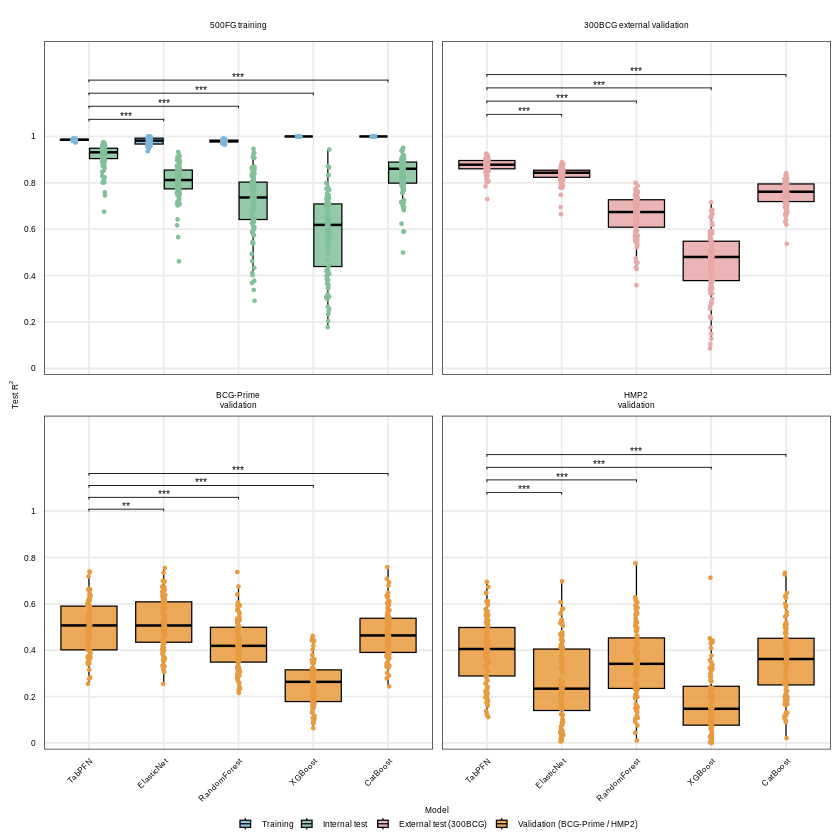

In [29]:
###add  2*2 panel
### Four panels: 2x2 facet grid; 500FG adds training metrics; BCG-Prime/HMP2 orange; Nature-style
model_levels <- c("TabPFN", "ElasticNet", "RandomForest", "XGBoost", "CatBoost")
panel_levels <- c("500FG", "300BCG", "BCG-Prime", "HMP2")

# Facet strip labels (BCG-Prime / HMP2 use a second line "validation")
panel_f_levels <- c(
  "500FG training",
  "300BCG external validation",
  "BCG-Prime\nvalidation",
  "HMP2\nvalidation"
)

# -------------------------------------------------------------------------
# 1) Long table: FillKey drives colors; 500FG includes Training + internal test
# -------------------------------------------------------------------------
plot_df_4panel <- bind_rows(
  tabpfn %>%
    transmute(Panel = "500FG", Model, Iteration, R2 = Train_R2, SetType = "Training"),
  tabpfn %>%
    transmute(Panel = "500FG", Model, Iteration, R2 = Test_R2, SetType = "Internal test"),
  tabpfn %>%
    transmute(Panel = "300BCG", Model, Iteration, R2 = External_R2, SetType = "External test"),
  bcg_prime_results %>%
    transmute(Panel = "BCG-Prime", Model, Iteration, R2 = Test_R2, SetType = "External test"),
  hmp2_results %>%
    transmute(Panel = "HMP2", Model, Iteration, R2 = Test_R2, SetType = "External test")
) %>%
  mutate(
    Model = factor(as.character(Model), levels = model_levels),
    Panel = factor(as.character(Panel), levels = panel_levels),
    SetType = factor(SetType, levels = c("Training", "Internal test", "External test")),
    Panel_f = factor(
      dplyr::case_when(
        as.character(Panel) == "500FG" ~ "500FG training",
        as.character(Panel) == "300BCG" ~ "300BCG external validation",
        as.character(Panel) == "BCG-Prime" ~ "BCG-Prime\nvalidation",
        as.character(Panel) == "HMP2" ~ "HMP2\nvalidation"
      ),
      levels = panel_f_levels
    ),
    FillKey = factor(
      dplyr::case_when(
        Panel == "500FG" & SetType == "Training" ~ "Training",
        Panel == "500FG" & SetType == "Internal test" ~ "Internal test",
        Panel == "300BCG" ~ "External test (300BCG)",
        TRUE ~ "Validation (BCG-Prime / HMP2)"
      ),
      levels = c(
        "Training",
        "Internal test",
        "External test (300BCG)",
        "Validation (BCG-Prime / HMP2)"
      )
    )
  ) %>%
  filter(!is.na(R2), Model %in% model_levels, !is.na(Panel))

# Paired tests: same as before (500FG uses internal test only; other cohorts unchanged)
plot_df_pval <- plot_df_4panel %>%
  dplyr::filter(Panel == "500FG" & SetType == "Internal test" | Panel != "500FG")

# -------------------------------------------------------------------------
# 2) Paired t-tests: TabPFN vs each other model within each panel
# -------------------------------------------------------------------------
wide_by_panel <- plot_df_pval %>%
  distinct(Panel, Iteration, Model, R2) %>%
  pivot_wider(names_from = Model, values_from = R2)

pval_df_4panel <- wide_by_panel %>%
  group_split(Panel) %>%
  map_dfr(function(w) {
    pn <- as.character(unique(w$Panel))
    others <- setdiff(names(w), c("Panel", "Iteration", "TabPFN"))
    map_dfr(others, function(m) {
      d <- w %>% select(Iteration, TabPFN, all_of(m)) %>% drop_na()
      if (nrow(d) < 2) {
        return(tibble(Panel = pn, group1 = "TabPFN", group2 = m, p = NA_real_))
      }
      tt <- t.test(d$TabPFN, d[[m]], paired = TRUE)
      tibble(Panel = pn, group1 = "TabPFN", group2 = m, p = tt$p.value)
    })
  }) %>%
  group_by(Panel) %>%
  mutate(p.adj = p.adjust(p, method = "BH")) %>%
  ungroup() %>%
  mutate(
    Panel = factor(as.character(Panel), levels = panel_levels),
    group1 = factor(group1, levels = model_levels),
    group2 = factor(group2, levels = model_levels),
    p.adj.signif = symnum(
      p.adj,
      corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1),
      symbols = c("***", "**", "*", ".", "ns")
    ),
    Panel_f = factor(
      dplyr::case_when(
        as.character(Panel) == "500FG" ~ "500FG training",
        as.character(Panel) == "300BCG" ~ "300BCG external validation",
        as.character(Panel) == "BCG-Prime" ~ "BCG-Prime\nvalidation",
        as.character(Panel) == "HMP2" ~ "HMP2\nvalidation"
      ),
      levels = panel_f_levels
    )
  )

panel_rng <- plot_df_4panel %>%
  group_by(Panel) %>%
  summarise(
    ymax = max(R2, na.rm = TRUE),
    span = pmax(max(R2, na.rm = TRUE) - min(R2, na.rm = TRUE), 1e-6),
    .groups = "drop"
  )

pval_df_4panel <- pval_df_4panel %>%
  left_join(panel_rng, by = "Panel") %>%
  group_by(Panel) %>%
  arrange(group2, .by_group = TRUE) %>%
  mutate(y.position = ymax + span * (0.05 + 0.04 * row_number())) %>%
  ungroup()

pval_df_4panel <- pval_df_4panel %>%
  mutate(
    y.position = if_else(
      Panel == "HMP2",
      y.position - 0.06 * span,
      y.position
    )
  )

print(pval_df_4panel)

# -------------------------------------------------------------------------
# 3) Plot (Nature-style): 2 rows x 2 cols = four panels; bottom legend
# -------------------------------------------------------------------------
axis_text_pt <- 5
axis_title_pt <- 5
strip_text_pt <- 5
title_pt <- 6

fill_manual <- c(
  "Training" = "#7EB6D9",
  "Internal test" = "#82C09A",
  "External test (300BCG)" = "#E8A8A8",
  "Validation (BCG-Prime / HMP2)" = "#E89A3E"
)

y_top <- max(c(plot_df_4panel$R2, pval_df_4panel$y.position), na.rm = TRUE) * 1.18

p4 <- ggplot(plot_df_4panel, aes(x = Model, y = R2, fill = FillKey)) +
  geom_boxplot(
    outlier.shape = NA,
    colour = "black",
    linewidth = 0.35,
    alpha = 0.85,
    position = position_dodge(width = 0.78)
  ) +
  geom_jitter(
    aes(color = FillKey),
     position = position_jitterdodge(jitter.width = 0.12, jitter.height = 0, dodge.width = 0.78),
     a = 0.7, size = 0.65,
    show.legend = FALSE
  ) +
  facet_wrap(~Panel_f, nrow = 2, ncol = 2, scales = "fixed") +
  scale_fill_manual(name = NULL, values = fill_manual) +
  scale_colour_manual(values = fill_manual, guide = "none") +
  scale_y_continuous(
    limits = c(0, y_top),
    breaks = seq(0, 1, 0.2),
    labels = function(x) ifelse(x <= 1, x, ""),
    expand = expansion(mult = c(0.02, 0.02))
  ) +
  labs(
    #title = "Validation",
    x = "Model",
    y = expression(Test ~ R^2)
  ) +
  theme_minimal(base_family = "sans") +
  theme(
    plot.title = element_text(size = title_pt, colour = "black", hjust = 0.5, margin = margin(b = 2)),
    axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
    axis.text.y = element_text(size = axis_text_pt, colour = "black"),
    axis.title = element_text(size = axis_title_pt, colour = "black"),
    strip.text = element_text(size = strip_text_pt, colour = "black", lineheight = 0.95),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.box = "horizontal",
    legend.box.spacing = unit(0.05, "cm"),
    legend.margin = margin(t = 0, b = 0),
    legend.key.size = unit(0.30, "cm"),
    legend.text = element_text(size = axis_text_pt, colour = "black"),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.35)
  ) +
  stat_pvalue_manual(
    data = pval_df_4panel,
    label = "p.adj.signif",
    xmin = "group1",
    xmax = "group2",
    y.position = "y.position",
    facet.by = "Panel_f",
    inherit.aes = FALSE,
    tip.length = 0.007,
    bracket.size = 0.24,
    step.increase = 0.02,
    hide.ns = FALSE,
    size = 2.2
  )

# -------------------------------------------------------------------------
# 4) Save (taller PDF for 2x2 layout)
# -------------------------------------------------------------------------
out_dir <- "/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

fig_w_mm <- 95
fig_h_mm <- 110
pdf_path <- file.path(out_dir, "validation_four_panels_22_nature.pdf")
csv_path <- file.path(out_dir, "validation_four_panels_22_paired_ttests.csv")

ggsave(
  filename = pdf_path,
  plot = p4,
  width = fig_w_mm / 25.4,
  height = fig_h_mm / 25.4,
  device = "pdf",
  useDingbats = FALSE
)

utils::write.csv(pval_df_4panel, csv_path, row.names = FALSE)

print(p4)
message("Saved:\n  ", pdf_path, "\n  ", csv_path)

# A tibble: 8 × 10
  Panel  group1 group2              p    p.adj p.adj.signif Panel_f   ymax  span
  <fct>  <fct>  <fct>           <dbl>    <dbl> <noquote>    <fct>    <dbl> <dbl>
1 500FG  TabPFN ElasticNet   5.02e-34 1.00e-33 ***          500FG t… 1.00  0.823
2 500FG  TabPFN RandomForest 5.21e-31 6.95e-31 ***          500FG t… 1.00  0.823
3 500FG  TabPFN XGBoost      2.57e-39 1.03e-38 ***          500FG t… 1.00  0.823
4 500FG  TabPFN CatBoost     1.75e-26 1.75e-26 ***          500FG t… 1.00  0.823
5 300BCG TabPFN ElasticNet   3.61e-17 3.61e-17 ***          300BCG … 0.926 0.840
6 300BCG TabPFN RandomForest 1.74e-43 2.31e-43 ***          300BCG … 0.926 0.840
7 300BCG TabPFN XGBoost      5.68e-55 2.27e-54 ***          300BCG … 0.926 0.840
8 300BCG TabPFN CatBoost     9.38e-45 1.88e-44 ***          300BCG … 0.926 0.840
# ℹ 1 more variable: y.position <dbl>


Saved:
  /vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/validation_two_panels_nature.pdf
  /vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation/validation_two_panels_paired_ttests.csv



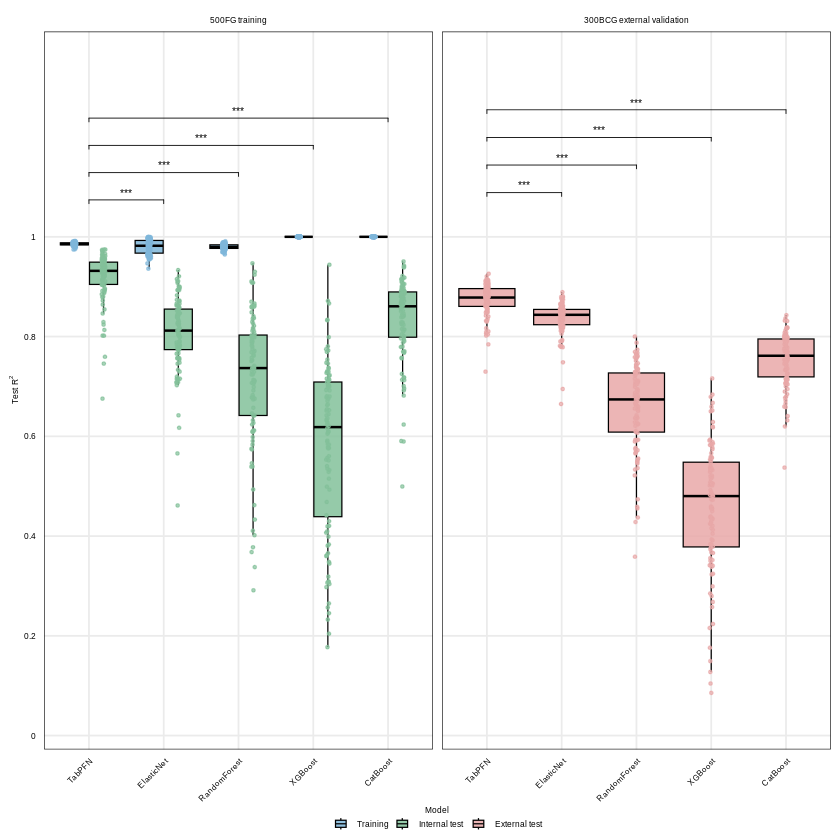

In [4]:
###only two cohort
# =========================================================
# Two-panel Nature-style plot: 500FG + 300BCG only
# =========================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(purrr)
  library(ggplot2)
  library(ggpubr)   # stat_pvalue_manual
})

# -----------------------------
# 0) Basic settings
# -----------------------------
model_levels <- c("TabPFN", "ElasticNet", "RandomForest", "XGBoost", "CatBoost")
panel_levels <- c("500FG", "300BCG")
panel_f_levels <- c(
  "500FG training",
  "300BCG external validation"
)

# -----------------------------
# 1) Long table (only 2 panels)
# -----------------------------
plot_df_2panel <- bind_rows(
  tabpfn %>%
    transmute(Panel = "500FG", Model, Iteration, R2 = Train_R2, SetType = "Training"),
  tabpfn %>%
    transmute(Panel = "500FG", Model, Iteration, R2 = Test_R2, SetType = "Internal test"),
  tabpfn %>%
    transmute(Panel = "300BCG", Model, Iteration, R2 = External_R2, SetType = "External test")
) %>%
  mutate(
    Model = factor(as.character(Model), levels = model_levels),
    Panel = factor(as.character(Panel), levels = panel_levels),
    SetType = factor(SetType, levels = c("Training", "Internal test", "External test")),
    Panel_f = factor(
      dplyr::case_when(
        as.character(Panel) == "500FG" ~ "500FG training",
        as.character(Panel) == "300BCG" ~ "300BCG external validation"
      ),
      levels = panel_f_levels
    ),
    FillKey = factor(
      dplyr::case_when(
        Panel == "500FG" & SetType == "Training" ~ "Training",
        Panel == "500FG" & SetType == "Internal test" ~ "Internal test",
        TRUE ~ "External test"
      ),
      levels = c("Training", "Internal test", "External test")
    )
  ) %>%
  filter(!is.na(R2), Model %in% model_levels, !is.na(Panel))


plot_df_pval <- plot_df_2panel %>%
  filter((Panel == "500FG" & SetType == "Internal test") | Panel == "300BCG")

# -----------------------------
# 2) Paired t-tests
#    TabPFN vs each other model
# -----------------------------
wide_by_panel <- plot_df_pval %>%
  distinct(Panel, Iteration, Model, R2) %>%
  pivot_wider(names_from = Model, values_from = R2)

pval_df_2panel <- wide_by_panel %>%
  group_split(Panel) %>%
  map_dfr(function(w) {
    pn <- as.character(unique(w$Panel))
    others <- setdiff(names(w), c("Panel", "Iteration", "TabPFN"))

    map_dfr(others, function(m) {
      d <- w %>% select(Iteration, TabPFN, all_of(m)) %>% tidyr::drop_na()
      if (nrow(d) < 2) {
        return(tibble(Panel = pn, group1 = "TabPFN", group2 = m, p = NA_real_))
      }
      tt <- t.test(d$TabPFN, d[[m]], paired = TRUE)
      tibble(Panel = pn, group1 = "TabPFN", group2 = m, p = tt$p.value)
    })
  }) %>%
  group_by(Panel) %>%
  mutate(p.adj = p.adjust(p, method = "BH")) %>%
  ungroup() %>%
  mutate(
    Panel = factor(as.character(Panel), levels = panel_levels),
    group1 = factor(group1, levels = model_levels),
    group2 = factor(group2, levels = model_levels),
    p.adj.signif = symnum(
      p.adj,
      corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1),
      symbols = c("***", "**", "*", ".", "ns")
    ),
    Panel_f = factor(
      dplyr::case_when(
        as.character(Panel) == "500FG" ~ "500FG training",
        as.character(Panel) == "300BCG" ~ "300BCG external validation"
      ),
      levels = panel_f_levels
    )
  )

panel_rng <- plot_df_2panel %>%
  group_by(Panel) %>%
  summarise(
    ymax = max(R2, na.rm = TRUE),
    span = pmax(max(R2, na.rm = TRUE) - min(R2, na.rm = TRUE), 1e-6),
    .groups = "drop"
  )

pval_df_2panel <- pval_df_2panel %>%
  left_join(panel_rng, by = "Panel") %>%
  group_by(Panel) %>%
  arrange(group2, .by_group = TRUE) %>%
  mutate(y.position = ymax + span * (0.05 + 0.04 * row_number())) %>%
  ungroup()

print(pval_df_2panel)

# -----------------------------
# 3) Plot (Nature-style): 1x2
# -----------------------------
axis_text_pt  <- 5
axis_title_pt <- 5
strip_text_pt <- 5
title_pt      <- 6

fill_manual <- c(
  "Training" = "#7EB6D9",
  "Internal test" = "#82C09A",
  "External test" = "#E8A8A8"
)

y_top <- max(c(plot_df_2panel$R2, pval_df_2panel$y.position), na.rm = TRUE) * 1.18

p2 <- ggplot(plot_df_2panel, aes(x = Model, y = R2, fill = FillKey)) +
  geom_boxplot(
    outlier.shape = NA,
    colour = "black",
    linewidth = 0.35,
    alpha = 0.85,
    position = position_dodge(width = 0.78)
  ) +
  geom_jitter(
    aes(color = FillKey),
    position = position_jitterdodge(
      jitter.width = 0.12,
      jitter.height = 0,
      dodge.width = 0.78
    ),
    alpha = 0.7,   
    size = 0.65,
    show.legend = FALSE
  ) +
  facet_wrap(~Panel_f, nrow = 1, ncol = 2, scales = "fixed") +
  scale_fill_manual(name = NULL, values = fill_manual) +
  scale_colour_manual(values = fill_manual, guide = "none") +
  scale_y_continuous(
    limits = c(0, y_top),
    breaks = seq(0, 1, 0.2),
    labels = function(x) ifelse(x <= 1, x, ""),
    expand = expansion(mult = c(0.02, 0.02))
  ) +
  labs(
    x = "Model",
    y = expression(Test ~ R^2)
  ) +
  theme_minimal(base_family = "sans") +
  theme(
    plot.title = element_text(size = title_pt, colour = "black", hjust = 0.5, margin = margin(b = 2)),
    axis.text.x = element_text(angle = 45, hjust = 1, size = axis_text_pt, colour = "black"),
    axis.text.y = element_text(size = axis_text_pt, colour = "black"),
    axis.title = element_text(size = axis_title_pt, colour = "black"),
    strip.text = element_text(size = strip_text_pt, colour = "black", lineheight = 0.95),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.box = "horizontal",
    legend.box.spacing = unit(0.05, "cm"),
    legend.margin = margin(t = 0, b = 0),
    legend.key.size = unit(0.30, "cm"),
    legend.text = element_text(size = axis_text_pt, colour = "black"),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.35)
  ) +
  stat_pvalue_manual(
    data = pval_df_2panel,
    label = "p.adj.signif",
    xmin = "group1",
    xmax = "group2",
    y.position = "y.position",
    facet.by = "Panel_f",
    inherit.aes = FALSE,
    tip.length = 0.007,
    bracket.size = 0.24,
    step.increase = 0.02,
    hide.ns = FALSE,
    size = 2.2
  )

# -----------------------------
# 4) Save
# -----------------------------
out_dir <- "/vol/projects/yzhang/300BCG/output/05_foundation_model/with_methylation"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

fig_w_mm <- 95
fig_h_mm <- 60
pdf_path <- file.path(out_dir, "validation_two_panels_nature.pdf")
csv_path <- file.path(out_dir, "validation_two_panels_paired_ttests.csv")

ggsave(
  filename = pdf_path,
  plot = p2,
  width = fig_w_mm / 25.4,
  height = fig_h_mm / 25.4,
  device = "pdf",
  useDingbats = FALSE
)

utils::write.csv(pval_df_2panel, csv_path, row.names = FALSE)

print(p2)
message("Saved:\n  ", pdf_path, "\n  ", csv_path)

In [45]:
###compare with current epi clocks
#EAA = read.csv("/vol/projects/yzhang/500FG_aging/input/DNAmAgeCalcProject_10275_Results.csv") #500FG
EAA = read.csv("/vol/projects/yzhang/300BCG/input/DNAmAgeCalcProject_10138_Results.csv")  #300BCG
rownames(EAA) <- EAA$SID
head(EAA)
dim(EAA)
epi_clock <- EAA %>%
  select(Age = Age,
         Horvath = DNAmAge,
         Hannum = DNAmAgeHannum,
         PhenoAge = DNAmPhenoAge,
         GrimAge = DNAmGrimAgeBasedOnRealAge)
head(epi_clock)

,SID,OriginalOrderInBatch,Plate_Number,Well_Address,Sentrix_ID,Sentrix_Position,Age,Tissue,Female,Sex,⋯,DNAmAgeSkinBloodClock,IEAA,IEAA.Hannum,EEAA,Epigenetic.Age..Zhang.,DNAmFitAge,DNAmGrimAge2BasedOnPredictedAge,DNAmGrimAge2BasedOnRealAge,DNAmGrimAgeBasedOnPredictedAge,DNAmGrimAgeBasedOnRealAge
,<chr>,<int>,<lgl>,<lgl>,<int>,<int>,<int>,<chr>,<int>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
X300BCG003_v1,X300BCG003_v1,1,NA,NA,1,1,22,blood wb,1,female,⋯,28.35317,1.826514,1.9640708,-1.3719306,NA,NA,43.88176,40.14893,44.32015,40.23197
X300BCG005_v1,X300BCG005_v1,2,NA,NA,2,2,18,blood wb,1,female,⋯,28.27396,-6.145256,-1.2436354,-1.8002073,NA,NA,51.31223,45.27574,48.82372,42.21257
X300BCG007_v1,X300BCG007_v1,3,NA,NA,3,3,25,blood wb,1,female,⋯,31.08807,-7.032479,-9.2386895,-13.2963428,NA,NA,52.20031,48.62325,49.90751,45.98992
X300BCG008_v1,X300BCG008_v1,4,NA,NA,4,4,22,blood wb,1,female,⋯,35.91665,11.959064,0.2597438,-0.8934917,NA,NA,56.00734,47.83057,55.65954,46.70436
X300BCG010_v1,X300BCG010_v1,5,NA,NA,5,5,20,blood wb,1,female,⋯,29.65347,-6.727431,1.9138859,6.4191263,NA,NA,50.62598,44.95406,51.09108,44.87920
X300BCG011_v1,X300BCG011_v1,6,NA,NA,6,6,24,blood wb,0,male,⋯,38.91770,2.566658,2.9758113,9.1497287,NA,NA,62.02666,53.26172,61.91365,52.31430


[1] 286 135

,Age,Horvath,Hannum,PhenoAge,GrimAge
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
X300BCG003_v1,22,23.76459,32.99755,-3.568376,40.23197
X300BCG005_v1,18,15.96973,31.97840,1.811255,42.21257
X300BCG007_v1,25,20.40511,27.94439,-1.640998,45.98992
X300BCG008_v1,22,36.60280,35.19005,20.013983,46.70436
X300BCG010_v1,20,17.56913,38.38424,9.623871,44.87920
X300BCG011_v1,24,31.94853,44.47858,14.404156,52.31430


In [6]:
models <- c("Horvath", "Hannum", "PhenoAge", "GrimAge")

results <- data.frame(
  Model = models,
  r = sapply(models, function(x) cor(epi_clock$Age, epi_clock[[x]], use = "complete.obs")),
  r2 = sapply(models, function(x) cor(epi_clock$Age, epi_clock[[x]], use = "complete.obs")^2)
)

print(results)

            Model         r        r2
Horvath   Horvath 0.8598762 0.7393870
Hannum     Hannum 0.8720587 0.7604865
PhenoAge PhenoAge 0.8062383 0.6500201
GrimAge   GrimAge 0.9446704 0.8924021


In [7]:
head(combined)

,Model,Iteration,Train_R2,Test_R2,External_R2,Train_RMSE,Test_RMSE,External_RMSE,Train_MSE,Test_MSE,External_MSE
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TabPFN,1,0.9861477,0.9491405,0.8863229,1.470556,3.667011,4.438085,2.162535,13.446968,19.69660
2,TabPFN,2,0.9899499,0.9661184,0.8853732,1.238447,2.966618,5.308985,1.533750,8.800823,28.18533
3,TabPFN,3,0.9822147,0.8239819,0.8063196,1.765089,4.638931,7.004709,3.115539,21.519677,49.06594
4,TabPFN,4,0.9869755,0.9614603,0.8779896,1.311251,2.615918,4.440516,1.719380,6.843028,19.71818
5,TabPFN,5,0.9876411,0.9310339,0.9141840,1.331928,3.424897,3.609033,1.774031,11.729919,13.02512
6,TabPFN,6,0.9851710,0.9366146,0.8626658,1.358598,3.706381,4.934813,1.845788,13.737256,24.35238


In [8]:
# Prepare ML data with both Internal (Train) and External (Test)
ml_data_long <- rbind(
  combined %>%
    filter(Model %in% c("TabPFN", "ElasticNet")) %>%
    select(Model, R2 = Test_R2) %>%
    mutate(Set = "Internal"),
  combined %>%
    filter(Model %in% c("TabPFN", "ElasticNet")) %>%
    select(Model, R2 = External_R2) %>%
    mutate(Set = "External")
)

# Combine with clock results
plot_data <- rbind(
  ml_data_long,
  results %>%
    select(Model, R2 = r2) %>%
    mutate(Set = "Clock")
)

plot_data$Model <- factor(plot_data$Model, 
                          levels = c("TabPFN", "ElasticNet", "Horvath", 
                                    "Hannum", "PhenoAge", "GrimAge"))
# Separate data
ml_internal <- plot_data %>% filter(Model %in% c("TabPFN", "ElasticNet"), Set == "Internal")
ml_external <- plot_data %>% filter(Model %in% c("TabPFN", "ElasticNet"), Set == "External")
clock_data <- plot_data %>% filter(Set == "Clock")

# Extract values
tabpfn_int <- ml_internal %>% filter(Model == "TabPFN") %>% pull(R2)
tabpfn_ext <- ml_external %>% filter(Model == "TabPFN") %>% pull(R2)
elasticnet_int <- ml_internal %>% filter(Model == "ElasticNet") %>% pull(R2)
elasticnet_ext <- ml_external %>% filter(Model == "ElasticNet") %>% pull(R2)

horvath <- clock_data %>% filter(Model == "Horvath") %>% pull(R2)
hannum <- clock_data %>% filter(Model == "Hannum") %>% pull(R2)
phenoage <- clock_data %>% filter(Model == "PhenoAge") %>% pull(R2)
grimage <- clock_data %>% filter(Model == "GrimAge") %>% pull(R2)

# Results table
results <- data.frame()

cat("Statistical Comparisons:\n")
cat(strrep("=", 80), "\n\n") 

# 1. TabPFN Internal vs External
cat("1. TabPFN: Internal vs External\n")
t1 <- t.test(tabpfn_int, tabpfn_ext, paired = TRUE)
results <- rbind(results, data.frame(
  Comparison = "TabPFN: Internal vs External",
  Diff = mean(tabpfn_int) - mean(tabpfn_ext),
  t = as.numeric(t1$statistic),
  p = t1$p.value
))
cat(sprintf("   Δ=%.4f, t=%.2f, p=%.4f\n\n", mean(tabpfn_int) - mean(tabpfn_ext), t1$statistic, t1$p.value))

# 2. ElasticNet Internal vs External
cat("2. ElasticNet: Internal vs External\n")
t2 <- t.test(elasticnet_int, elasticnet_ext, paired = TRUE)
results <- rbind(results, data.frame(
  Comparison = "ElasticNet: Internal vs External",
  Diff = mean(elasticnet_int) - mean(elasticnet_ext),
  t = as.numeric(t2$statistic),
  p = t2$p.value
))
cat(sprintf("   Δ=%.4f, t=%.2f, p=%.4f\n\n", mean(elasticnet_int) - mean(elasticnet_ext), t2$statistic, t2$p.value))

# 3. TabPFN vs ElasticNet (for each set)
cat("3. TabPFN vs ElasticNet:\n")
t3 <- t.test(tabpfn_int, elasticnet_int, paired = TRUE)
results <- rbind(results, data.frame(
  Comparison = "TabPFN vs ElasticNet (Internal)",
  Diff = mean(tabpfn_int) - mean(elasticnet_int),
  t = as.numeric(t3$statistic),
  p = t3$p.value
))
cat(sprintf("   Internal: Δ=%.4f, t=%.2f, p=%.4f\n", mean(tabpfn_int) - mean(elasticnet_int), t3$statistic, t3$p.value))

t4 <- t.test(tabpfn_ext, elasticnet_ext, paired = TRUE)
results <- rbind(results, data.frame(
  Comparison = "TabPFN vs ElasticNet (External)",
  Diff = mean(tabpfn_ext) - mean(elasticnet_ext),
  t = as.numeric(t4$statistic),
  p = t4$p.value
))
cat(sprintf("   External: Δ=%.4f, t=%.2f, p=%.4f\n\n", mean(tabpfn_ext) - mean(elasticnet_ext), t4$statistic, t4$p.value))

# 4. ML (External) vs Clocks
cat("4. ML models (External) vs Clocks:\n")
clocks <- list(Horvath = horvath, Hannum = hannum, PhenoAge = phenoage, GrimAge = grimage)

for(ml_name in c("TabPFN", "ElasticNet")) {
  ml_vals <- if(ml_name == "TabPFN") tabpfn_ext else elasticnet_ext
  
  for(clock_name in names(clocks)) {
    t_res <- t.test(ml_vals, mu = clocks[[clock_name]])
    
    results <- rbind(results, data.frame(
      Comparison = paste(ml_name, "vs", clock_name),
      Diff = mean(ml_vals) - clocks[[clock_name]],
      t = as.numeric(t_res$statistic),
      p = t_res$p.value
    ))
    
    cat(sprintf("   %s vs %s: Δ=%.4f, t=%.2f, p=%.4f\n",
               ml_name, clock_name, mean(ml_vals) - clocks[[clock_name]], 
               t_res$statistic, t_res$p.value))
  }
}

# Bonferroni correction
results$p_adj <- p.adjust(results$p, method = "bonferroni")
results$sig <- ifelse(results$p_adj < 0.001, "***",
                     ifelse(results$p_adj < 0.01, "**",
                           ifelse(results$p_adj < 0.05, "*", "ns")))

cat("\n5. After Bonferroni correction:\n")
print(results[, c("Comparison", "Diff", "p", "p_adj", "sig")])

Statistical Comparisons:

1. TabPFN: Internal vs External
   Δ=0.0446, t=8.46, p=0.0000

2. ElasticNet: Internal vs External
   Δ=0.0569, t=13.94, p=0.0000

3. TabPFN vs ElasticNet:
   Internal: Δ=0.0054, t=1.22, p=0.2271
   External: Δ=0.0178, t=3.74, p=0.0003

4. ML models (External) vs Clocks:
   TabPFN vs Horvath: Δ=0.1340, t=41.79, p=0.0000
   TabPFN vs Hannum: Δ=0.1129, t=35.21, p=0.0000
   TabPFN vs PhenoAge: Δ=0.2234, t=69.66, p=0.0000
   TabPFN vs GrimAge: Δ=-0.0190, t=-5.93, p=0.0000
   ElasticNet vs Horvath: Δ=0.1162, t=38.43, p=0.0000
   ElasticNet vs Hannum: Δ=0.0951, t=31.45, p=0.0000
   ElasticNet vs PhenoAge: Δ=0.2056, t=67.97, p=0.0000
   ElasticNet vs GrimAge: Δ=-0.0368, t=-12.15, p=0.0000

5. After Bonferroni correction:
                         Comparison         Diff            p        p_adj sig
1      TabPFN: Internal vs External  0.044581253 2.508803e-13 3.010564e-12 ***
2  ElasticNet: Internal vs External  0.056947214 4.408970e-25 5.290764e-24 ***
3   TabPFN vs

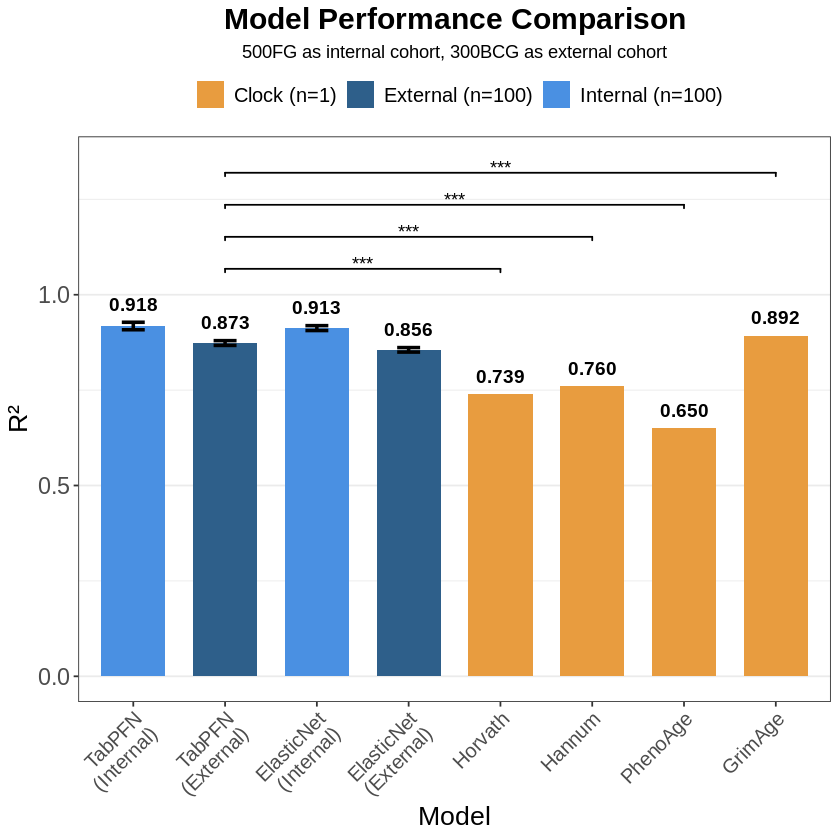

In [9]:
ml_stats <- plot_data %>%
  filter(Set != "Clock") %>%
  group_by(Model, Set) %>%
  summarise(
    R2_mean = mean(R2),
    R2_sd = sd(R2),
    n = n(),
    .groups = 'drop'
  ) %>%
  mutate(
    SE = R2_sd / sqrt(n),
    error_upper = R2_mean + 1.96 * SE,
    error_lower = R2_mean - 1.96 * SE
  )

# Clock data
clock_stats <- plot_data %>%
  filter(Set == "Clock") %>%
  select(Model, Set, R2) %>%
  mutate(
    R2_mean = R2,
    R2_sd = 0,
    n = 1,
    SE = 0,
    error_upper = R2,
    error_lower = R2
  )

# Combine summaries
plot_summary <- rbind(
  ml_stats %>% select(Model, Set, R2 = R2_mean, n, SE, error_upper, error_lower),
  clock_stats %>% select(Model, Set, R2 = R2_mean, n, SE, error_upper, error_lower)
)

# Create Model_Type labels
plot_summary$Model_Type <- paste0(plot_summary$Model,
                                   ifelse(plot_summary$Set == "Clock", "",
                                         paste0("\n(", plot_summary$Set, ")")))

plot_summary$Model_Type <- factor(plot_summary$Model_Type,
                                   levels = c("TabPFN\n(Internal)", "TabPFN\n(External)",
                                            "ElasticNet\n(Internal)", "ElasticNet\n(External)",
                                            "Horvath", "Hannum", "PhenoAge", "GrimAge"))

# Calculate text label positions
plot_summary$text_y <- plot_summary$error_upper + 0.03
max_text_y <- max(plot_summary$text_y, na.rm = TRUE)

pval_df <- results %>%
  filter(grepl("TabPFN vs", Comparison) & !grepl("Internal", Comparison)) %>%
  mutate(
    group1 = "TabPFN\n(External)",
    group2 = case_when(
      grepl("Horvath", Comparison) ~ "Horvath",
      grepl("Hannum", Comparison) ~ "Hannum",
      grepl("PhenoAge", Comparison) ~ "PhenoAge",
      grepl("GrimAge", Comparison) ~ "GrimAge",
      TRUE ~ NA_character_
    ),
    p.adj.signif = sig
  ) %>%
  filter(!is.na(group2)) %>%
  select(group1, group2, p.value = p, p.adj = p_adj, p.adj.signif)

# Calculate bracket positions
base_bracket_y <- max_text_y + 0.05
pval_df$y.position <- base_bracket_y + 0.06 * (1:nrow(pval_df))

# Calculate y-axis upper limit
y_upper <- max(pval_df$y.position, na.rm = TRUE) * 1.08


# Plot
p <- ggplot(plot_summary, aes(x = Model_Type, y = R2)) +
  geom_bar(aes(fill = Set), stat = "identity", width = 0.7) +
  geom_errorbar(data = subset(plot_summary, n > 1),
                aes(ymin = error_lower, ymax = error_upper),
                width = 0.25, linewidth = 1, color = "black") +
  geom_text(aes(y = text_y, label = sprintf("%.3f", R2)),
            vjust = 0, size = 4, fontface = "bold") +
  stat_pvalue_manual(
    pval_df,
    label = "p.adj.signif",
    xmin = "group1",
    xmax = "group2",
    y.position = "y.position",
    tip.length = 0.015,
    bracket.size = 0.5,
    step.increase = 0.04,
    textsize = 5,
    hide.ns = TRUE
  ) +
  scale_fill_manual(
    values = c("Internal" = "#4A90E2",
               "External" = "#2E5F8A",
               "Clock" = "#E89C3F"),
    labels = c("Internal" = "Internal (n=100)",
               "External" = "External (n=100)",
               "Clock" = "Clock (n=1)")
  ) +
  labs(
    title = "Model Performance Comparison",
    subtitle = "500FG as internal cohort, 300BCG as external cohort",
    x = "Model",
    y = "R²",
    fill = ""
  ) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 14),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 18, hjust = 0.5, face = "bold"),
    plot.subtitle = element_text(size = 11, hjust = 0.5),
    legend.position = "top",
    legend.text = element_text(size = 12),
    panel.grid.major.x = element_blank()
  ) +
  ylim(0, y_upper)

print(p)

ggsave("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison_final.pdf", p, width = 14, height = 10, dpi = 300, bg = "white")

In [55]:
save.image("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison.Rdata")

In [2]:
load("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison.Rdata")

In [48]:
save.image("/vol/projects/yzhang/300BCG/output/05_foundation_model/300bcg_model_epi_clock_comparison_cross_cohort.Rdata")